# 📞 PreCall AI
### Cost-Aware Lead Scoring for Bank Term Deposit Campaigns

*Predicting who's worth calling — before a single call is placed.*

---

**Dataset:** Direct marketing campaign data from a Portuguese retail bank (2008–2010), [hosted on UCI](https://archive.ics.uci.edu/dataset/222/bank+marketing) — 41,188 contacts.

**Objective:** Predict whether a customer will subscribe to a term deposit *before* a call is placed, so limited call-center capacity can be prioritized toward the highest-propensity customers — without leaking the call outcome itself into the model.

**Pipeline:**
`EDA` → `Preprocessing` → `Baseline Models` → `Hyperparameter Tuning` → `Model Selection` → `Advanced Layer (SHAP · Cost-ROI · Clustering · Temporal Validation · Model Persistence)`

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_curve, precision_recall_curve, average_precision_score)
from sklearn.utils.class_weight import compute_class_weight

import xgboost as xgb
import lightgbm as lgb

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 100)
print("Libraries loaded.")


Libraries loaded.


## Phase 1: Exploratory Data Analysis (EDA)

### 1.1 Basic Exploration

In [4]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
print("Shape:", df.shape)
df.head()


Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [7]:
df.describe(include='object').T


,count,unique,top,freq
job,41188,12,admin.,10422
marital,41188,4,married,24928
education,41188,8,university.degree,12168
default,41188,3,no,32588
housing,41188,3,yes,21576
loan,41188,3,no,33950
contact,41188,2,cellular,26144
month,41188,10,may,13769
day_of_week,41188,5,thu,8623
poutcome,41188,3,nonexistent,35563


**Observations:**
- 41,188 rows, 21 columns. No literal NaN values, but several categorical columns use the string `"unknown"` as a placeholder for missing data (visible in `describe(include='object')` as a category).
- `pdays` has a max of 999, which is a **sentinel value** meaning "client was never previously contacted" — not a genuine numeric measurement. This will need special handling, not naive scaling.
- Numeric ranges look plausible (age 17–98, campaign contacts 1–56) — no obviously corrupted values.
- The 5 macro-economic columns (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`) are national quarterly/monthly indicators, so they take a small number of repeated values across many rows (they describe *when* a client was contacted, not the client themselves).

### 1.2 Target Variable Analysis

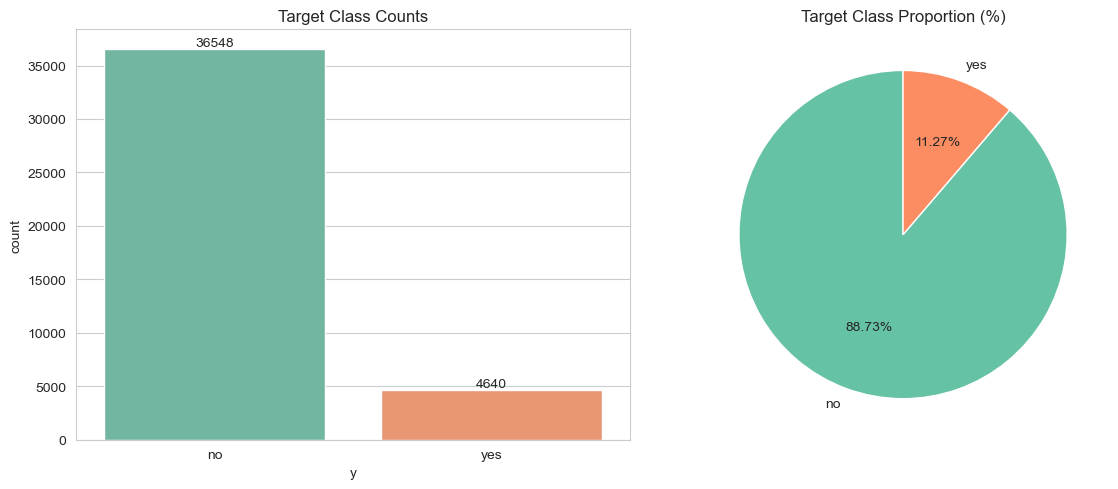

y
no     36548
yes     4640
Name: count, dtype: int64
y
no     88.73
yes    11.27
Name: proportion, dtype: float64


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='y', hue='y', palette='Set2', legend=False, ax=ax[0])
ax[0].set_title("Target Class Counts")
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                   ha='center', va='bottom')

vc = df['y'].value_counts(normalize=True) * 100
ax[1].pie(vc, labels=vc.index, autopct='%1.2f%%', colors=sns.color_palette('Set2'), startangle=90)
ax[1].set_title("Target Class Proportion (%)")
plt.tight_layout()
plt.show()

print(df['y'].value_counts())
print((df['y'].value_counts(normalize=True)*100).round(2))


**Class imbalance: 88.73% `no` vs 11.27% `yes`** — roughly an **8:1 ratio**. This is a textbook imbalanced classification problem. A naive model that always predicts "no" would already score 88.73% accuracy while being completely useless to the business, which is exactly why accuracy alone will be rejected as a success metric later in this notebook (see Phase 4).

### 1.3 Feature-Level Scrutiny — Numerical Distributions

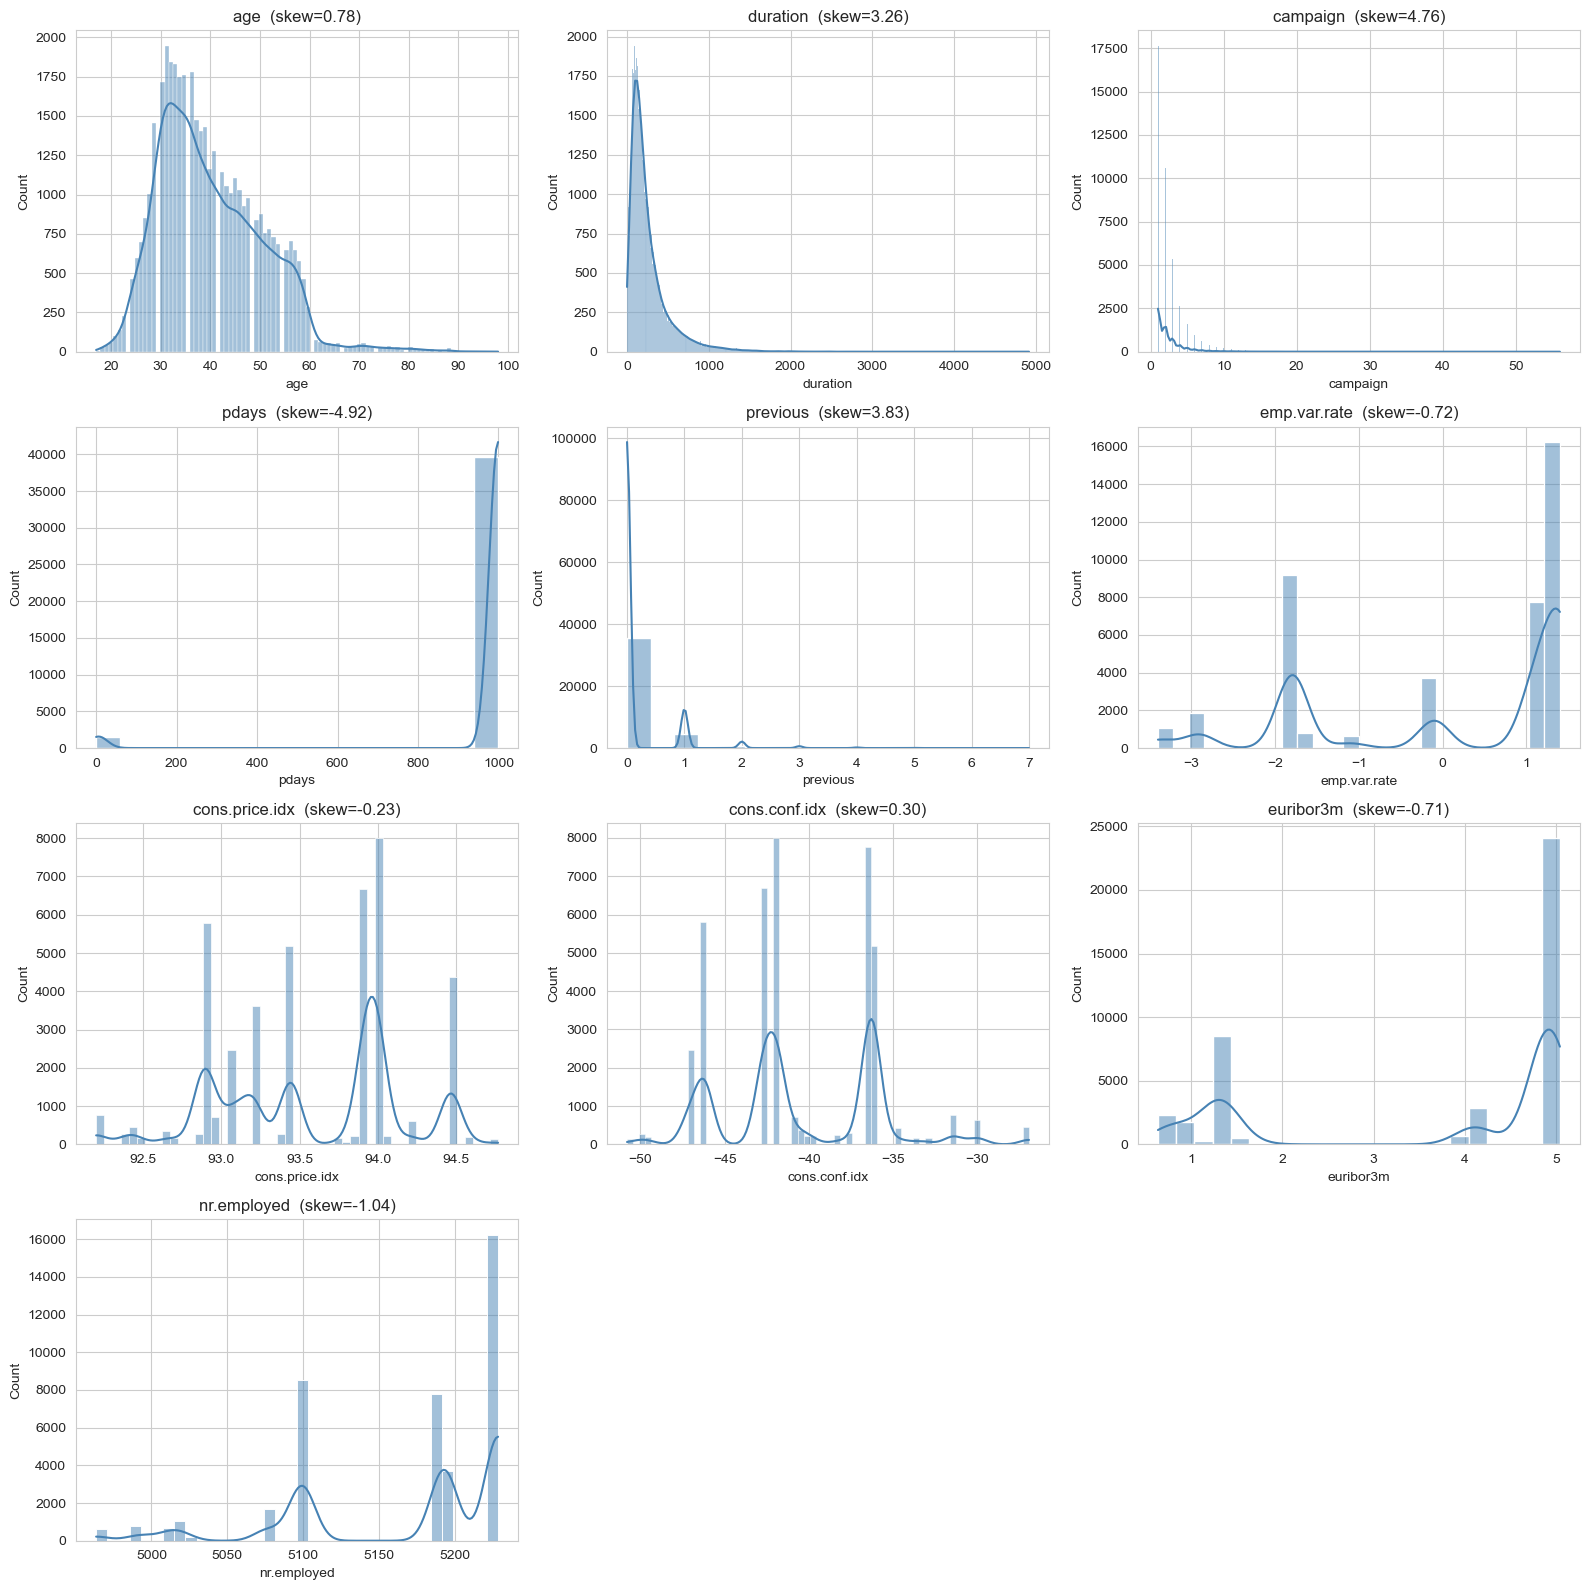

In [13]:
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f"{col}  (skew={df[col].skew():.2f})")
for ax in axes.flatten()[len(num_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


**Observations:**
- `age` is right-skewed (skew ≈ 0.78) but genuinely continuous — a real candidate for power-transformation.
- `duration` and `campaign` and `previous` are heavily right-skewed (skew 3–5). `duration` will be dropped (leakage). `previous` is **zero-inflated** (most clients were never contacted before, so the value is 0) — this is a count variable with a spike at zero, not a smooth skewed continuous variable, so a log/Box-Cox transform would distort rather than help it; it needs capping/flagging instead.
- `pdays` shows a single dominant spike at 999 (no previous contact) — this is **not real numeric data**, it's a sentinel/placeholder. Scaling or transforming it directly would be statistically meaningless. We will engineer a binary flag from it instead.
- The 5 macro-economic indicators are step-like / multi-modal, reflecting that they only change monthly or quarterly while many client rows share the same time period. They should **not** be skew-corrected — their shape reflects real economic regime changes, not noise.

### 1.4 Boxplots — Numerical Features vs Target

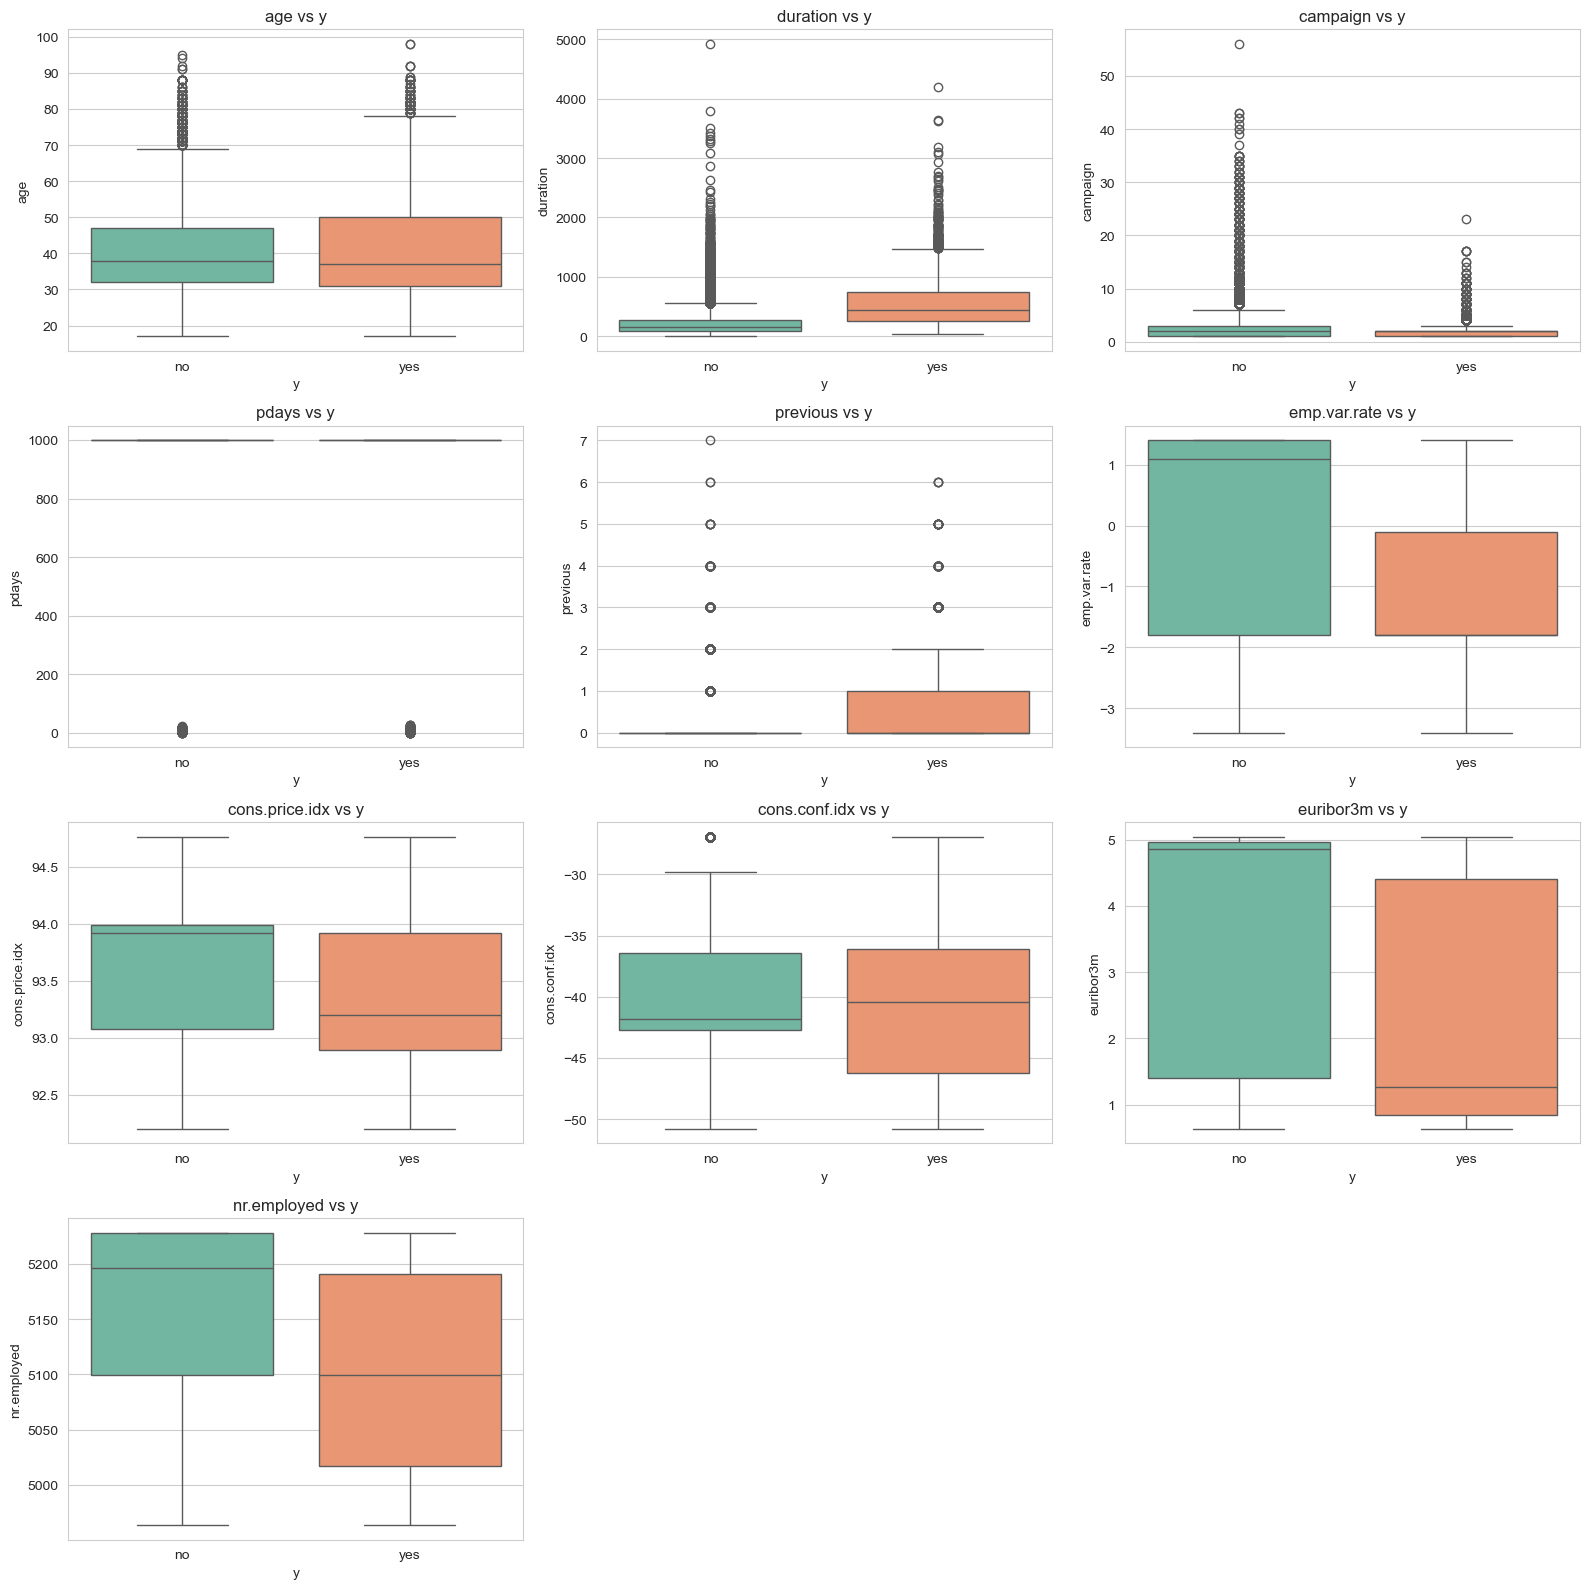

In [16]:
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df, x='y', y=col, hue='y', palette='Set2', legend=False, ax=ax)
    ax.set_title(f"{col} vs y")
for ax in axes.flatten()[len(num_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


**Observations:**
- `duration` is dramatically higher for `yes` (longer calls correlate with successful sales) — visually the strongest split of any feature, which is exactly why it must be excluded from a pre-call predictive model.
- `previous` and `pdays` show clear separation: clients who were contacted before (and especially those with a prior **success**) are much more likely to subscribe again.
- `emp.var.rate`, `euribor3m`, and `nr.employed` show visibly lower values for the `yes` class — clients subscribed more during weaker macro-economic periods (when interest rates / employment were lower, deposits may have looked more attractive, or campaigns were timed differently). This is a genuine, actionable macro signal, not noise.
- `age` shows wider spread and more outliers among subscribers, hinting at sub-segments (e.g., students, retirees) — confirmed in the categorical analysis below.

### 1.5 Categorical Features vs Target

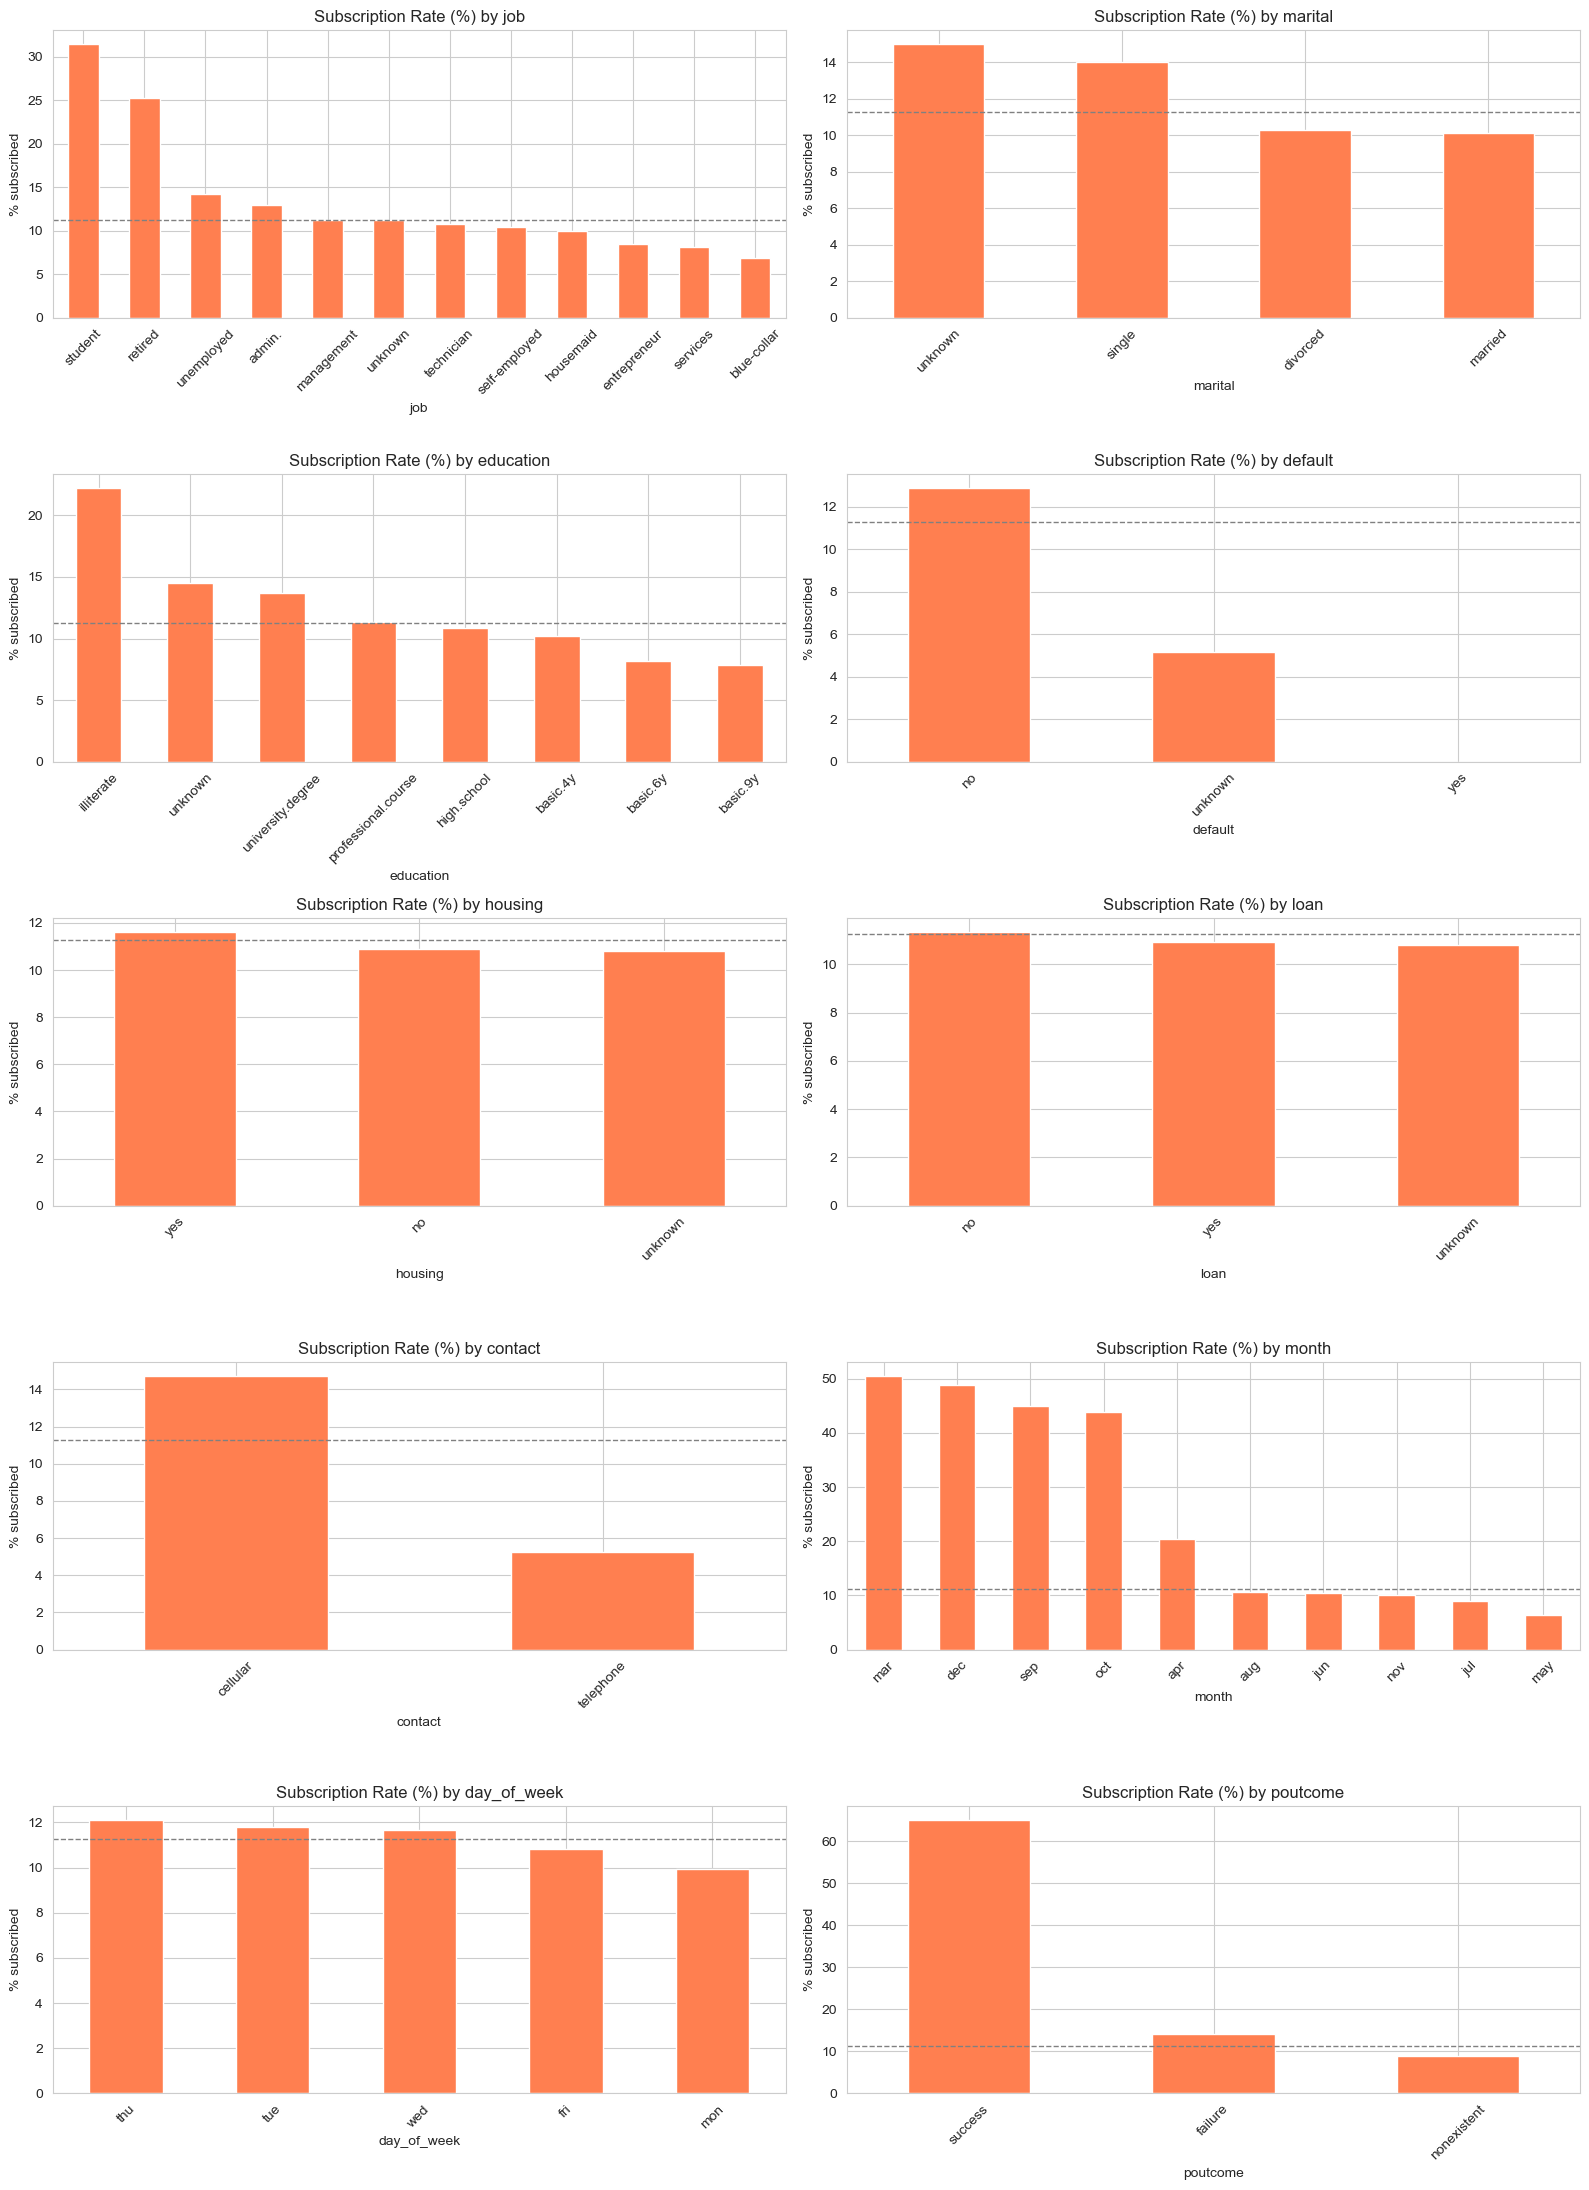

In [19]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'day_of_week', 'poutcome']

fig, axes = plt.subplots(5, 2, figsize=(16, 22))
for ax, col in zip(axes.flatten(), cat_cols):
    ct = pd.crosstab(df[col], df['y'], normalize='index') * 100
    ct['yes'].sort_values(ascending=False).plot(kind='bar', ax=ax, color='coral')
    ax.set_title(f"Subscription Rate (%) by {col}")
    ax.set_ylabel("% subscribed")
    ax.axhline(df['y'].eq('yes').mean()*100, color='gray', linestyle='--', linewidth=1)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Observations (dashed line = overall 11.27% base rate):**
- **`job`:** students (~31%) and retirees (~25%) convert far above average; blue-collar workers convert well below average (~7%).
- **`default`:** clients with `default = yes` essentially never subscribe (~0%) — almost no signal there since the group is tiny, but `default = unknown` also converts notably lower than `default = no`, suggesting `unknown` correlates with risk and is informative, not just "missing."
- **`contact`:** cellular contact converts at ~14.7% vs ~5.2% for telephone — channel choice alone is a ~3x lever.
- **`month`:** huge swings — March, December, September, October convert 40–50%+, while May (the busiest contact month) converts only ~6.4%. This strongly suggests campaign timing/seasonality interacts with which months campaigns were even run, and probably correlates with the macro-economic regime at that time.
- **`poutcome`:** prior campaign success drives ~65% conversion vs ~14% for prior failure and ~8.8% for no prior contact — by far the single strongest categorical signal in the dataset.
- **`education`:** a mild, fairly monotonic increase in conversion with more formal education, with `illiterate` clients (a very small group) showing the highest rate — likely a small-sample effect worth flagging rather than over-interpreting.

### 1.6 Correlation Analysis

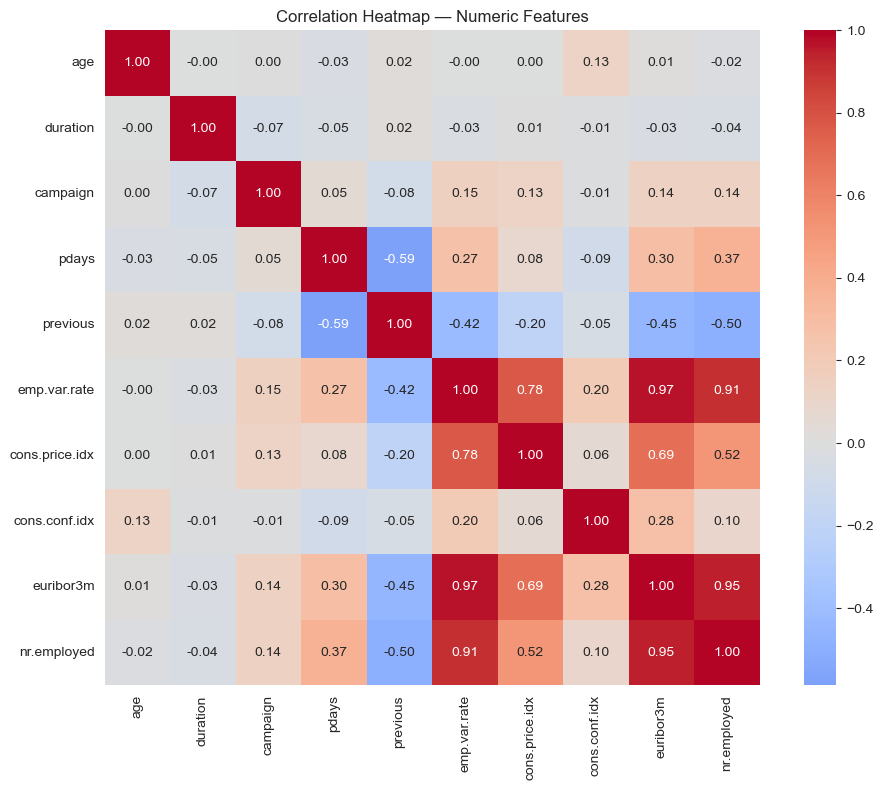

In [22]:
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()


**Observations — severe multicollinearity among the macro-economic block:**
- `emp.var.rate` ↔ `euribor3m`: **0.97**
- `emp.var.rate` ↔ `nr.employed`: **0.91**
- `euribor3m` ↔ `nr.employed`: **0.95**
- `emp.var.rate` ↔ `cons.price.idx`: **0.78**

These four (`emp.var.rate`, `cons.price.idx`, `euribor3m`, `nr.employed`) move together because they all reflect the same underlying economic cycle. This is **not a problem for tree-based models** (Random Forest, XGBoost, LightGBM, Gradient Boosting are invariant to collinearity), but it **inflates coefficient variance in Logistic Regression** and can slow/destabilize SVM convergence. We keep all features for tree models and flag this explicitly when interpreting Logistic Regression coefficients later — we do not silently drop columns, since that would remove information that boosting models can still exploit.
- `pdays` and `previous` are negatively correlated (-0.59), consistent with them encoding overlapping "was this client contacted before" information — motivating the `was_contacted_before` engineered flag in Phase 2.

### 1.7 EDA Summary (Task 1 deliverable)

| Finding | Business meaning |
|---|---|
| 88.7% / 11.3% class imbalance | Accuracy is a misleading success metric; need F1/PR-AUC and resampling/class-weighting |
| `duration` is the strongest raw predictor | Unusable for targeting decisions — must be excluded to avoid leakage |
| `poutcome = success` → 65% conversion | Past responders are the single best group to re-target |
| `month` swings from 6% (May) to 50%+ (Mar/Dec/Sep/Oct) | Campaign timing matters enormously — investigate why these months differ |
| `contact = cellular` more than 2x `telephone` | Channel selection is a cheap, high-leverage lever |
| `job = student/retired` convert 2–3x the average | Under-served high-value segments for targeting |
| Macro indicators are highly collinear with each other | Affects linear models; tree models unaffected |
| `pdays` is 96%+ sentinel value (999) | Needs flag engineering, not direct scaling |


## Phase 2: Data Preprocessing

We build a **leak-free** pipeline: every transformer (power transform, scaler, encoder) is fit **only on the training partition** after the train/test split, then applied to the test partition. All decisions below are justified against the EDA findings above.

### 2.1 Drop the leakage column

In [27]:
df_clean = df.drop(columns=['duration'])
print("Shape after dropping duration:", df_clean.shape)


Shape after dropping duration: (41188, 20)


### 2.2 Constant columns (zero variance)

In [29]:
const_cols = [c for c in df_clean.columns if df_clean[c].nunique() <= 1]
print("Constant columns found:", const_cols)


Constant columns found: []


No constant columns exist in this dataset — nothing to drop here.

### 2.3 Unique identifier / high-cardinality columns

In [32]:
print(df_clean.nunique().sort_values(ascending=False))
print("\nAny column unique per row (ID-like)?", any(df_clean.nunique() == len(df_clean)))


euribor3m         316
age                78
campaign           42
pdays              27
cons.conf.idx      26
cons.price.idx     26
job                12
nr.employed        11
month              10
emp.var.rate       10
previous            8
education           8
day_of_week         5
marital             4
default             3
poutcome            3
loan                3
housing             3
contact             2
y                   2
dtype: int64

Any column unique per row (ID-like)? False


No ID/hash-like column is present — the dataset contains no row identifier, so there is nothing to drop on cardinality grounds. `euribor3m` has 316 unique values but is a genuine continuous economic indicator, not an identifier.

### 2.4 Duplicate records

**Important nuance:** duplicates must be checked *after* removing `duration`. With `duration` included there were only 12 duplicate rows (since call length is almost always unique), but once we remove it — which we must, for leakage reasons — we find clients who are identical across every remaining feature.

In [35]:
dupes_before = df_clean.duplicated().sum()
print("Duplicate rows (after dropping duration):", dupes_before)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Shape after deduplication:", df_clean.shape)


Duplicate rows (after dropping duration): 1784
Shape after deduplication: (39404, 20)


### 2.5 Null / "unknown" value handling

There are no literal NaNs, but six categorical columns use the string `"unknown"` as a missing-value placeholder.

In [37]:
cat_cols_check = df_clean.select_dtypes(include='object').columns.tolist()
cat_cols_check.remove('y')
unknown_summary = {}
for c in cat_cols_check:
    n = (df_clean[c] == 'unknown').sum()
    if n > 0:
        unknown_summary[c] = (n, round(n/len(df_clean)*100, 2))
pd.DataFrame(unknown_summary, index=['count', 'pct']).T


,count,pct
job,325.0,0.82
marital,79.0,0.20
education,1686.0,4.28
default,8266.0,20.98
housing,980.0,2.49
loan,980.0,2.49


**Decision:** keep `"unknown"` as its own explicit category rather than imputing with the mode or dropping rows. Justification:
- `default` is 20.9% `unknown` — dropping or mode-imputing this many rows would destroy nearly a quarter of the dataset's information and bias the remaining sample.
- The EDA already showed `default = unknown` has a *different* subscription rate than `default = no`, meaning "unknown" carries real signal (it is not missing-at-random) — collapsing it into the mode would erase a genuine pattern the model can use.
- For the remaining columns (`job`, `marital`, `education`, `housing`, `loan`) unknown rates are low (0.2%–4.3%), but for consistency and to avoid arbitrary imputation, we keep `"unknown"` as a category everywhere it appears — one-hot encoding naturally turns it into its own informative column.

No numerical column has missing values, so no mean/median imputation is required.

### 2.6 Feature engineering on `pdays`

`pdays = 999` is a sentinel for "never contacted before," not a real numeric distance. We convert this into an explicit binary flag and drop the now-redundant raw column (it overlaps almost perfectly with `poutcome` and `previous`, as shown in the EDA crosstab below).

In [40]:
df_clean['was_contacted_before'] = (df_clean['pdays'] != 999).astype(int)
print(pd.crosstab(df_clean['was_contacted_before'], df_clean['poutcome']))
df_clean = df_clean.drop(columns=['pdays'])
print("\nShape after pdays engineering:", df_clean.shape)


poutcome              failure  nonexistent  success
was_contacted_before                               
0                        4032        33858        0
1                         142            0     1372

Shape after pdays engineering: (39404, 20)


The crosstab confirms `was_contacted_before = 0` aligns almost exactly with `poutcome = nonexistent`, and `= 1` aligns with `failure`/`success` — so the new flag captures the same information as `pdays` in a clean, scale-free way, and `poutcome` still carries the *outcome* (not just the fact of prior contact), so both are kept.

### 2.7 Target encoding

In [43]:
df_clean['y'] = df_clean['y'].map({'no': 0, 'yes': 1})
df_clean['y'].value_counts()


y
0    34806
1     4598
Name: count, dtype: int64

### 2.8 Train/test split (before any further transform fitting)

We split first and fit every remaining transformer only on `X_train`, to guarantee zero leakage from test into train.

In [45]:
X = df_clean.drop(columns=['y'])
y = df_clean['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain target balance:\n", y_train.value_counts(normalize=True).round(4))
print("\nTest target balance:\n", y_test.value_counts(normalize=True).round(4))


Train shape: (31523, 19)  Test shape: (7881, 19)

Train target balance:
 y
0    0.8833
1    0.1167
Name: proportion, dtype: float64

Test target balance:
 y
0    0.8833
1    0.1167
Name: proportion, dtype: float64


`stratify=y` ensures both partitions preserve the 88.7/11.3 class ratio, so test performance is representative of the true imbalance.

### 2.9 Outlier handling (IQR capping) and skew correction

`age` and `campaign` are genuinely continuous and skewed → Yeo-Johnson power transform (chosen over Box-Cox because `campaign` and other features can be zero, and Yeo-Johnson supports zero/negative values, unlike Box-Cox which requires strictly positive input). `previous` is a zero-inflated count, not a smooth skewed continuous variable, so it is capped at its 99th percentile instead of power-transformed (a transform would not fix a spike-at-zero distribution).

All capping thresholds and the power transform are **fit on `X_train` only**, then applied to `X_test`.

In [48]:
# IQR-based capping for age and campaign (fit thresholds on train only)
outlier_cols = ['age', 'campaign']
cap_bounds = {}
for c in outlier_cols:
    q1, q3 = X_train[c].quantile(0.25), X_train[c].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    cap_bounds[c] = (lower, upper)
    n_train = ((X_train[c] < lower) | (X_train[c] > upper)).sum()
    print(f"{c}: bounds=({lower:.2f}, {upper:.2f}), train outliers capped={n_train}")
    X_train[c] = X_train[c].clip(lower=lower, upper=upper)
    X_test[c] = X_test[c].clip(lower=lower, upper=upper)  # same bounds applied to test, no refitting

# previous: cap at 99th percentile of TRAIN only
prev_cap = X_train['previous'].quantile(0.99)
print(f"\nprevious: capping at train 99th percentile = {prev_cap}")
X_train['previous'] = X_train['previous'].clip(upper=prev_cap)
X_test['previous'] = X_test['previous'].clip(upper=prev_cap)


age: bounds=(9.50, 69.50), train outliers capped=375
campaign: bounds=(-2.00, 6.00), train outliers capped=1922

previous: capping at train 99th percentile = 2.0


In [49]:
pt = PowerTransformer(method='yeo-johnson')
X_train[outlier_cols] = pt.fit_transform(X_train[outlier_cols])
X_test[outlier_cols] = pt.transform(X_test[outlier_cols])

print("Skew after Yeo-Johnson (train):")
print(X_train[outlier_cols].skew())


Skew after Yeo-Johnson (train):
age         0.004061
campaign    0.201900
dtype: float64


### 2.10 Categorical encoding

All categorical features have low-to-moderate cardinality (max 12 categories for `job`). One-Hot Encoding is appropriate throughout — there is no need for target/label encoding, which would risk leakage and is better reserved for very high-cardinality features (hundreds+ categories), none of which exist here.

In [51]:
cat_cols_all = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                'contact', 'month', 'day_of_week', 'poutcome']

X_train_enc = pd.get_dummies(X_train, columns=cat_cols_all, drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=cat_cols_all, drop_first=True)

# align in case any category present in train is absent in test or vice versa
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

print("Encoded shapes:", X_train_enc.shape, X_test_enc.shape)
print("Columns identical:", list(X_train_enc.columns) == list(X_test_enc.columns))


Encoded shapes: (31523, 52) (7881, 52)
Columns identical: True


`drop_first=True` avoids the dummy-variable trap (perfect multicollinearity from redundant indicator columns), which matters for Logistic Regression and SVM.

### 2.11 Feature scaling

StandardScaler is applied to all numeric (non-binary) columns, fit on train only. **Scaling is mandatory** for:
- **Distance-based algorithms (SVM):** the algorithm computes distances/margins in feature space; unscaled features with larger numeric ranges (e.g. `nr.employed` ~5000) would dominate over small-range features (e.g. `previous` ~0-2), distorting the decision boundary.
- **Gradient-based algorithms (Logistic Regression, the Keras ANN):** gradient descent converges far faster and more reliably when features share a comparable scale; unscaled inputs cause uneven, slow, or unstable convergence.

Tree-based models (Decision Tree, Random Forest, AdaBoost, Gradient Boosting, XGBoost, LightGBM) are scale-invariant by construction, but we apply one consistent preprocessed dataset to every model for a fair, reproducible comparison — it does not hurt their performance.

In [54]:
numeric_for_scaling = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx',
                       'cons.conf.idx', 'euribor3m', 'nr.employed']

scaler = StandardScaler()
X_train_enc[numeric_for_scaling] = scaler.fit_transform(X_train_enc[numeric_for_scaling])
X_test_enc[numeric_for_scaling] = scaler.transform(X_test_enc[numeric_for_scaling])

X_train_enc[numeric_for_scaling].describe().loc[['mean', 'std']]


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
mean,1.442589e-17,-5.139224e-17,1.244233e-16,1.329887e-17,-1.202815e-14,-1.446646e-15,6.288787e-17,-1.224938e-14
std,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00


### 2.12 Handling class imbalance — SMOTE on the training partition only

SMOTE (Synthetic Minority Over-sampling Technique) is applied **only to `X_train_enc`/`y_train`**, never to the test set — the test set must stay untouched and reflect the real-world 88.7/11.3 distribution, otherwise evaluation metrics would be optimistic and meaningless for deployment.

We also compute `class_weight='balanced'` as an alternative for models where it is more natural (Logistic Regression, SVM, tree-based models, ANN) — both strategies are explored across the model suite below rather than picking one universally, since some algorithms handle weighting more gracefully than synthetic resampling.

In [56]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_enc, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", y_train_sm.value_counts().to_dict())


Before SMOTE: {0: 27845, 1: 3678}
After SMOTE : {0: 27845, 1: 27845}


In [57]:
class_weights_arr = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("Class weights:", class_weight_dict)


Class weights: {0: 0.5660441731010953, 1: 4.285345296356716}


**Final preprocessed objects used throughout the rest of the notebook:**
- `X_train_enc`, `y_train` — original imbalanced training data (used with `class_weight='balanced'` models)
- `X_train_sm`, `y_train_sm` — SMOTE-balanced training data (used for models trained on resampled data)
- `X_test_enc`, `y_test` — untouched, real-world-distributed test data (used for **every** model's final evaluation)

## Phase 3: Model Building

We separate features/target, confirm the split already performed above (Phase 2.8), and train 9 algorithms: Logistic Regression, SVM, Decision Tree, Random Forest, AdaBoost, Gradient Boosting, XGBoost, LightGBM, and a Keras MLP/ANN.

For each model we print **Accuracy, Precision, Recall, F1-Score, ROC-AUC**, a classification report, and a confusion matrix, using one centralized evaluation function (defined first) to guarantee every model is judged identically.

In [60]:
def evaluate_model(model, X_test, y_test, model_name="Model", is_keras=False, threshold=0.5):
    """Centralized evaluation: prints all key metrics, classification report,
    and plots a confusion matrix heatmap. Returns a dict of metrics for later comparison."""
    if is_keras:
        y_proba = model.predict(X_test, verbose=0).ravel()
        y_pred = (y_proba >= threshold).astype(int)
    else:
        y_pred = model.predict(X_test)
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_proba = model.decision_function(X_test)
        else:
            y_proba = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_test, y_proba)
    except Exception:
        auc = np.nan
    pr_auc = average_precision_score(y_test, y_proba)

    print(f"{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['no', 'yes'], zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['no', 'yes'], yticklabels=['no', 'yes'], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1-Score": f1, "ROC-AUC": auc, "PR-AUC": pr_auc
    }

results = []  # collects every model's metrics dict for the Phase 5 comparison


### 3.1 Logistic Regression (baseline)

Trained with `class_weight='balanced'` on the original (non-SMOTE) training data — a standard, interpretable baseline.

  Logistic Regression
Accuracy : 0.8277
Precision: 0.3660
Recall   : 0.6500
F1-Score : 0.4683
ROC-AUC  : 0.7942
PR-AUC   : 0.4691

Classification Report:
              precision    recall  f1-score   support

          no       0.95      0.85      0.90      6961
         yes       0.37      0.65      0.47       920

    accuracy                           0.83      7881
   macro avg       0.66      0.75      0.68      7881
weighted avg       0.88      0.83      0.85      7881



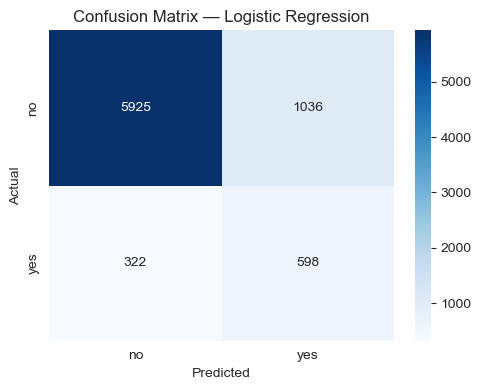

In [62]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_enc, y_train)
results.append(evaluate_model(log_reg, X_test_enc, y_test, "Logistic Regression"))


### 3.2 Support Vector Machine (SVM)

SVM is computationally expensive on large datasets (training time scales poorly with rows), so we train on the **SMOTE-balanced** set with an RBF kernel and `probability=True` to enable ROC-AUC scoring. Kernel tuning is explored later in Phase 4's hyperparameter search.

  SVM (RBF kernel)
Accuracy : 0.8552
Precision: 0.4069
Recall   : 0.5250
F1-Score : 0.4585
ROC-AUC  : 0.7564
PR-AUC   : 0.3860

Classification Report:
              precision    recall  f1-score   support

          no       0.93      0.90      0.92      6961
         yes       0.41      0.53      0.46       920

    accuracy                           0.86      7881
   macro avg       0.67      0.71      0.69      7881
weighted avg       0.87      0.86      0.86      7881



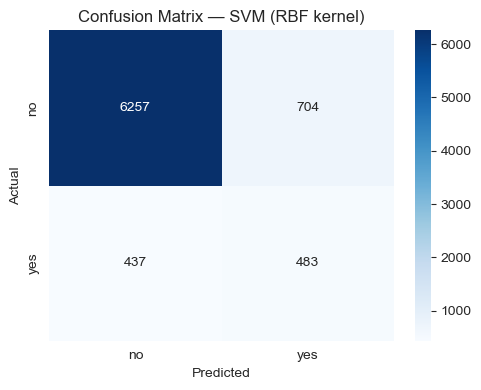

In [64]:
svm_clf = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE)
svm_clf.fit(X_train_sm, y_train_sm)
results.append(evaluate_model(svm_clf, X_test_enc, y_test, "SVM (RBF kernel)"))


### 3.3 Decision Tree Classifier

  Decision Tree
Accuracy : 0.8070
Precision: 0.3227
Recall   : 0.5946
F1-Score : 0.4184
ROC-AUC  : 0.7429
PR-AUC   : 0.4185

Classification Report:
              precision    recall  f1-score   support

          no       0.94      0.84      0.88      6961
         yes       0.32      0.59      0.42       920

    accuracy                           0.81      7881
   macro avg       0.63      0.71      0.65      7881
weighted avg       0.87      0.81      0.83      7881



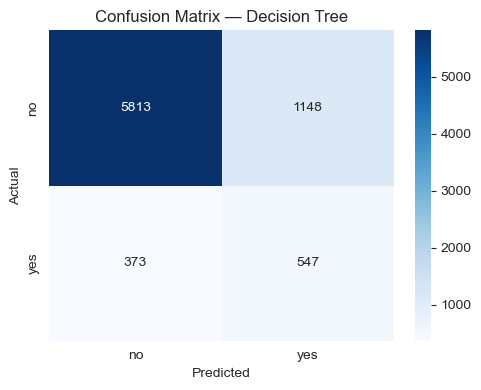

In [66]:
dt_clf = DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=RANDOM_STATE)
dt_clf.fit(X_train_enc, y_train)
results.append(evaluate_model(dt_clf, X_test_enc, y_test, "Decision Tree"))


### 3.4 Random Forest Classifier

  Random Forest
Accuracy : 0.8925
Precision: 0.5765
Recall   : 0.2989
F1-Score : 0.3937
ROC-AUC  : 0.7724
PR-AUC   : 0.4354

Classification Report:
              precision    recall  f1-score   support

          no       0.91      0.97      0.94      6961
         yes       0.58      0.30      0.39       920

    accuracy                           0.89      7881
   macro avg       0.74      0.63      0.67      7881
weighted avg       0.87      0.89      0.88      7881



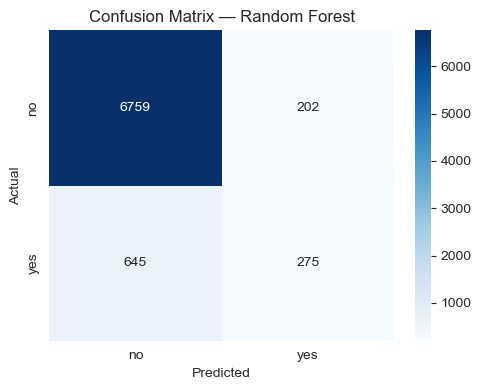

In [68]:
rf_clf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                 max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_train_enc, y_train)
results.append(evaluate_model(rf_clf, X_test_enc, y_test, "Random Forest"))


### 3.5 AdaBoost Classifier

AdaBoost has no native `class_weight` parameter, so it is trained on the SMOTE-balanced set instead.

  AdaBoost
Accuracy : 0.8430
Precision: 0.3835
Recall   : 0.5674
F1-Score : 0.4577
ROC-AUC  : 0.7666
PR-AUC   : 0.4230

Classification Report:
              precision    recall  f1-score   support

          no       0.94      0.88      0.91      6961
         yes       0.38      0.57      0.46       920

    accuracy                           0.84      7881
   macro avg       0.66      0.72      0.68      7881
weighted avg       0.87      0.84      0.86      7881



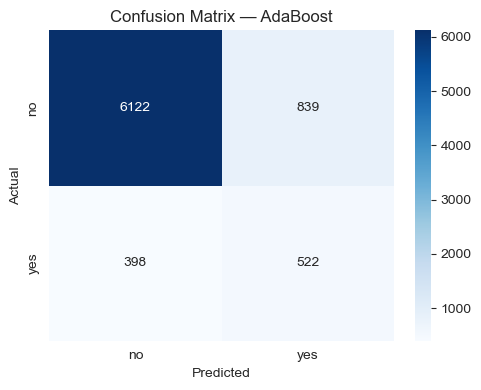

In [70]:
ada_clf = AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE)
ada_clf.fit(X_train_sm, y_train_sm)
results.append(evaluate_model(ada_clf, X_test_enc, y_test, "AdaBoost"))


### 3.6 Gradient Boosting Classifier

Also trained on the SMOTE-balanced set (no native class-weight support in scikit-learn's implementation).

  Gradient Boosting
Accuracy : 0.8718
Precision: 0.4570
Recall   : 0.5196
F1-Score : 0.4863
ROC-AUC  : 0.7839
PR-AUC   : 0.4459

Classification Report:
              precision    recall  f1-score   support

          no       0.94      0.92      0.93      6961
         yes       0.46      0.52      0.49       920

    accuracy                           0.87      7881
   macro avg       0.70      0.72      0.71      7881
weighted avg       0.88      0.87      0.88      7881



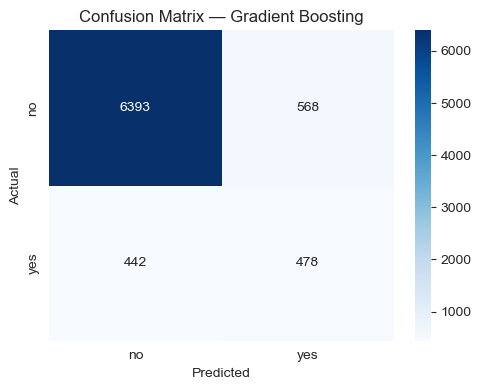

In [72]:
gb_clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE)
gb_clf.fit(X_train_sm, y_train_sm)
results.append(evaluate_model(gb_clf, X_test_enc, y_test, "Gradient Boosting"))


### 3.7 XGBoost Classifier

Uses `scale_pos_weight` (XGBoost's native imbalance handling) on the original training data rather than SMOTE, which is the recommended approach for boosted trees per the XGBoost documentation.

scale_pos_weight: 7.571
  XGBoost
Accuracy : 0.8381
Precision: 0.3823
Recall   : 0.6283
F1-Score : 0.4753
ROC-AUC  : 0.7941
PR-AUC   : 0.4897

Classification Report:
              precision    recall  f1-score   support

          no       0.95      0.87      0.90      6961
         yes       0.38      0.63      0.48       920

    accuracy                           0.84      7881
   macro avg       0.66      0.75      0.69      7881
weighted avg       0.88      0.84      0.85      7881



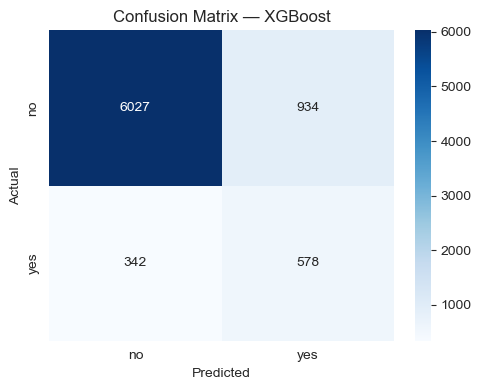

In [74]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 3))

xgb_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='logloss',
    random_state=RANDOM_STATE, use_label_encoder=False
)
xgb_clf.fit(X_train_enc, y_train)
results.append(evaluate_model(xgb_clf, X_test_enc, y_test, "XGBoost"))


### 3.8 LightGBM Classifier

Uses `is_unbalance=True` (LightGBM's native imbalance handling) on the original training data.

  LightGBM
Accuracy : 0.8429
Precision: 0.3914
Recall   : 0.6228
F1-Score : 0.4807
ROC-AUC  : 0.7935
PR-AUC   : 0.4948

Classification Report:
              precision    recall  f1-score   support

          no       0.95      0.87      0.91      6961
         yes       0.39      0.62      0.48       920

    accuracy                           0.84      7881
   macro avg       0.67      0.75      0.69      7881
weighted avg       0.88      0.84      0.86      7881



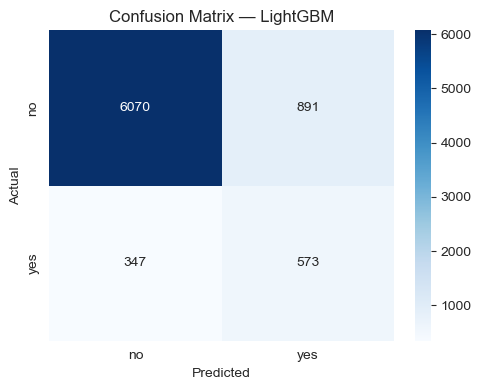

In [76]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=200, max_depth=-1, learning_rate=0.1,
    is_unbalance=True, random_state=RANDOM_STATE, verbose=-1
)
lgb_clf.fit(X_train_enc, y_train)
results.append(evaluate_model(lgb_clf, X_test_enc, y_test, "LightGBM"))


### 3.9 Deep Learning Model — Multilayer Perceptron (ANN)

Architecture: Input → Dense(64, ReLU) → Dropout(0.3) → Dense(32, ReLU) → Dropout(0.3) → Dense(1, Sigmoid). Trained on the SMOTE-balanced set with Adam optimizer and binary cross-entropy loss. Dropout layers combat overfitting given the model has many more parameters than a typical sklearn model relative to the dataset size.

In [78]:
n_features = X_train_sm.shape[1]

ann_model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

ann_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           3,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,505 (21.50 KB)

 Trainable params: 5,505 (21.50 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = ann_model.fit(
    X_train_sm, y_train_sm,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7441 - loss: 0.5525 - val_accuracy: 0.5818 - val_loss: 0.7059
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7743 - loss: 0.5018 - val_accuracy: 0.6220 - val_loss: 0.6433
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7871 - loss: 0.4732 - val_accuracy: 0.6725 - val_loss: 0.5947
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7991 - loss: 0.4563 - val_accuracy: 0.7007 - val_loss: 0.5680
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8056 - loss: 0.4411 - val_accuracy: 0.7253 - val_loss: 0.5361
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8123 - loss: 0.4300 - val_accuracy: 0.7384 - val_loss: 0.5170
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8189 - loss: 0.4209 - val_accuracy: 0.7399 - val_loss: 0.5102
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8240 - loss: 0.4086 - val_accuracy: 0.

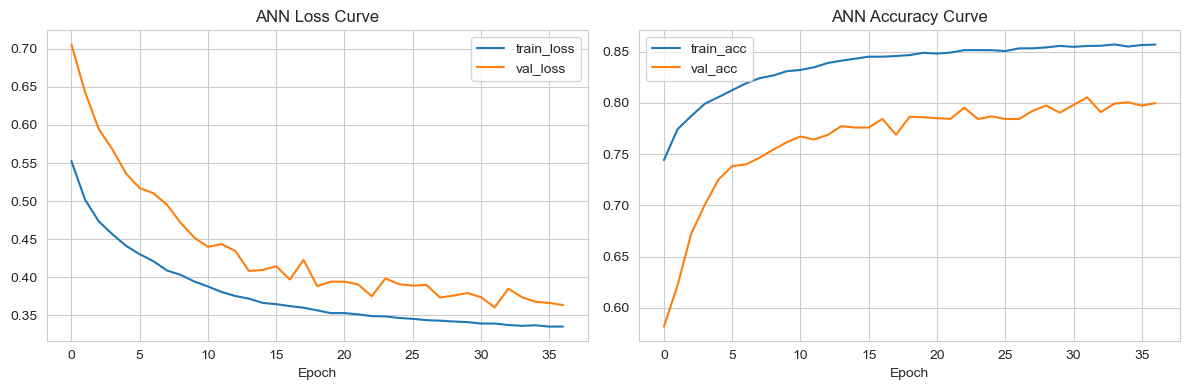

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='train_loss')
ax[0].plot(history.history['val_loss'], label='val_loss')
ax[0].set_title("ANN Loss Curve")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(history.history['accuracy'], label='train_acc')
ax[1].plot(history.history['val_accuracy'], label='val_acc')
ax[1].set_title("ANN Accuracy Curve")
ax[1].set_xlabel("Epoch")
ax[1].legend()
plt.tight_layout()
plt.show()


  ANN (Keras MLP)
Accuracy : 0.8735
Precision: 0.4499
Recall   : 0.3761
F1-Score : 0.4097
ROC-AUC  : 0.7600
PR-AUC   : 0.3906

Classification Report:
              precision    recall  f1-score   support

          no       0.92      0.94      0.93      6961
         yes       0.45      0.38      0.41       920

    accuracy                           0.87      7881
   macro avg       0.68      0.66      0.67      7881
weighted avg       0.86      0.87      0.87      7881



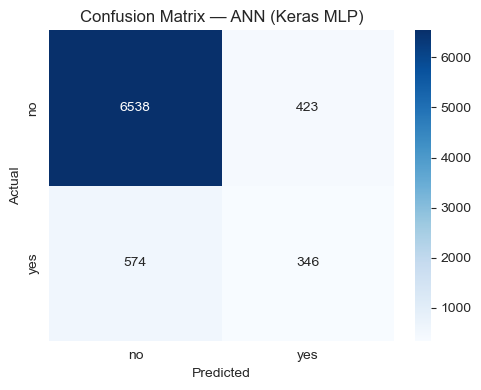

In [81]:
X_train_enc = X_train_enc.astype(np.float64)
X_test_enc = X_test_enc.astype(np.float64)
results.append(evaluate_model(ann_model, X_test_enc.values, y_test, "ANN (Keras MLP)", is_keras=True))


## Phase 4: Hyperparameter Tuning & Evaluation

We run `GridSearchCV`/`RandomizedSearchCV` (5-fold stratified, F1-scored) on three top tree/ensemble candidates: Random Forest, XGBoost, and LightGBM. F1 is used as the search metric — not accuracy — for the same reason explained below.

In [83]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


### 4.1 Random Forest — GridSearchCV

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'max_depth': 12, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1: 0.4967
  Random Forest (Tuned)
Accuracy : 0.8606
Precision: 0.4305
Recall   : 0.6022
F1-Score : 0.5020
ROC-AUC  : 0.8006
PR-AUC   : 0.4896

Classification Report:
              precision    recall  f1-score   support

          no       0.94      0.89      0.92      6961
         yes       0.43      0.60      0.50       920

    accuracy                           0.86      7881
   macro avg       0.69      0.75      0.71      7881
weighted avg       0.88      0.86      0.87      7881



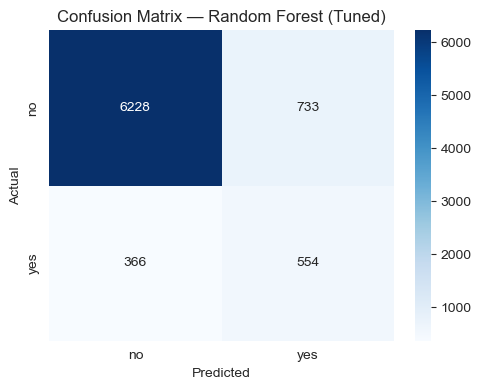

In [85]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=rf_param_grid, scoring='f1', cv=cv_strategy, n_jobs=-1, verbose=1
)
rf_grid.fit(X_train_enc, y_train)
print("Best params:", rf_grid.best_params_)
print("Best CV F1:", round(rf_grid.best_score_, 4))

rf_best = rf_grid.best_estimator_
results.append(evaluate_model(rf_best, X_test_enc, y_test, "Random Forest (Tuned)"))


### 4.2 XGBoost — RandomizedSearchCV

`RandomizedSearchCV` is used here instead of an exhaustive grid because the XGBoost search space is larger — random search reaches comparable optima at a fraction of the compute cost.

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best CV F1: 0.4852
  XGBoost (Tuned)
Accuracy : 0.8533
Precision: 0.4141
Recall   : 0.6185
F1-Score : 0.4961
ROC-AUC  : 0.8032
PR-AUC   : 0.4964

Classification Report:
              precision    recall  f1-score   support

          no       0.95      0.88      0.91      6961
         yes       0.41      0.62      0.50       920

    accuracy                           0.85      7881
   macro avg       0.68      0.75      0.71      7881
weighted avg       0.88      0.85      0.87      7881



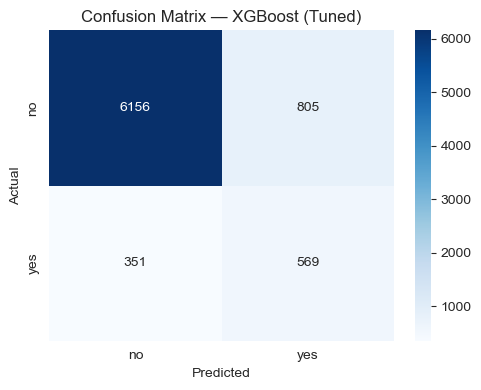

In [87]:
xgb_param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss',
                       random_state=RANDOM_STATE, use_label_encoder=False),
    param_distributions=xgb_param_dist, n_iter=25, scoring='f1',
    cv=cv_strategy, n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
xgb_search.fit(X_train_enc, y_train)
print("Best params:", xgb_search.best_params_)
print("Best CV F1:", round(xgb_search.best_score_, 4))

xgb_best = xgb_search.best_estimator_
results.append(evaluate_model(xgb_best, X_test_enc, y_test, "XGBoost (Tuned)"))


### 4.3 LightGBM — RandomizedSearchCV

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'num_leaves': 127, 'n_estimators': 100, 'learning_rate': 0.01, 'feature_fraction': 0.8}
Best CV F1: 0.5026
  LightGBM (Tuned)
Accuracy : 0.8758
Precision: 0.4733
Recall   : 0.5674
F1-Score : 0.5161
ROC-AUC  : 0.7993
PR-AUC   : 0.4920

Classification Report:
              precision    recall  f1-score   support

          no       0.94      0.92      0.93      6961
         yes       0.47      0.57      0.52       920

    accuracy                           0.88      7881
   macro avg       0.71      0.74      0.72      7881
weighted avg       0.89      0.88      0.88      7881



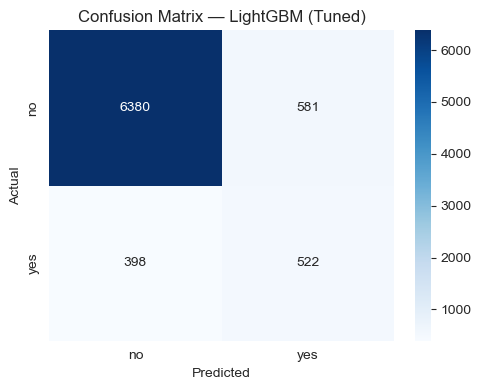

In [89]:
lgb_param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'num_leaves': [15, 31, 63, 127],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'feature_fraction': [0.7, 0.8, 1.0]
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(is_unbalance=True, random_state=RANDOM_STATE, verbose=-1),
    param_distributions=lgb_param_dist, n_iter=25, scoring='f1',
    cv=cv_strategy, n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
lgb_search.fit(X_train_enc, y_train)
print("Best params:", lgb_search.best_params_)
print("Best CV F1:", round(lgb_search.best_score_, 4))

lgb_best = lgb_search.best_estimator_
results.append(evaluate_model(lgb_best, X_test_enc, y_test, "LightGBM (Tuned)"))


### 4.4 Why Accuracy is misleading here — and why F1 / PR-AUC is the right metric

With an 88.7% / 11.3% split, a trivial model that **always predicts "no"** scores **88.7% accuracy** while identifying zero subscribers — completely worthless to the marketing team, whose entire goal is to find the rare "yes" clients. Accuracy treats both classes as equally important, but here they are not: missing a genuine subscriber (false negative) costs the bank a lost sale, while wrongly calling a non-subscriber (false positive) only costs a few minutes of agent time. 

**F1-Score** (the harmonic mean of Precision and Recall on the minority "yes" class) directly measures the trade-off the bank actually cares about: catching as many real subscribers as possible (recall) without flooding agents with too many wasted calls (precision). **PR-AUC** is reported alongside F1 because it summarizes this trade-off across *all* decision thresholds, which matters since the bank can tune the calling threshold based on agent capacity — ROC-AUC, by contrast, can look artificially optimistic on highly imbalanced data because it's diluted by the very large true-negative count. For this project, **F1-Score on the "yes" class is the primary success metric**, with PR-AUC as a robustness check.

### 4.5 Feature Importance — Best Tree-Based Model

Best tree-based model by F1: LightGBM (Tuned)


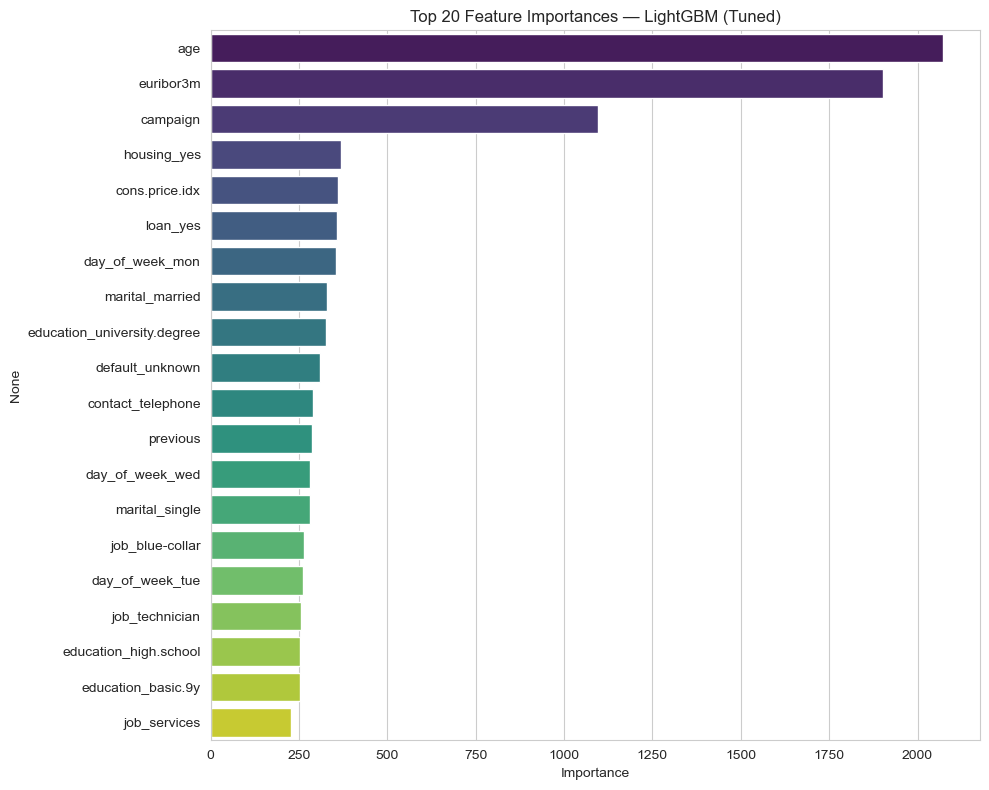

age                            2073
euribor3m                      1903
campaign                       1095
housing_yes                     368
cons.price.idx                  362
loan_yes                        358
day_of_week_mon                 354
marital_married                 329
education_university.degree     328
default_unknown                 311
contact_telephone               289
previous                        288
day_of_week_wed                 280
marital_single                  280
job_blue-collar                 265
day_of_week_tue                 261
job_technician                  257
education_high.school           254
education_basic.9y              253
job_services                    229
dtype: int32

In [92]:
# Pick whichever tuned tree-based model scored highest F1 on test
tree_candidates = {r['Model']: r for r in results if r['Model'] in
                    ['Random Forest (Tuned)', 'XGBoost (Tuned)', 'LightGBM (Tuned)']}
best_tree_name = max(tree_candidates, key=lambda k: tree_candidates[k]['F1-Score'])
print("Best tree-based model by F1:", best_tree_name)

best_tree_model = {'Random Forest (Tuned)': rf_best,
                    'XGBoost (Tuned)': xgb_best,
                    'LightGBM (Tuned)': lgb_best}[best_tree_name]

importances = pd.Series(best_tree_model.feature_importances_, index=X_train_enc.columns)
importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette='viridis', legend=False)
plt.title(f"Top 20 Feature Importances — {best_tree_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances


## Phase 5: Conclusion & Analytical Summary

### 5.1 Model Comparison

In [95]:
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM (Tuned),0.875777,0.473255,0.567391,0.516065,0.799307,0.492015
1,Random Forest (Tuned),0.860551,0.430458,0.602174,0.502039,0.800635,0.489613
2,XGBoost (Tuned),0.853318,0.414119,0.618478,0.496077,0.803203,0.496353
3,Gradient Boosting,0.871844,0.456979,0.519565,0.486267,0.783931,0.445916
4,LightGBM,0.842913,0.391393,0.622826,0.480705,0.793476,0.494797
5,XGBoost,0.838092,0.382275,0.628261,0.475329,0.794053,0.489680
6,Logistic Regression,0.827687,0.365973,0.650000,0.468285,0.794202,0.469077
7,SVM (RBF kernel),0.855221,0.406908,0.525000,0.458472,0.756375,0.386005
8,AdaBoost,0.843040,0.383542,0.567391,0.457694,0.766599,0.422967
9,Decision Tree,0.807004,0.322714,0.594565,0.418356,0.742907,0.418497


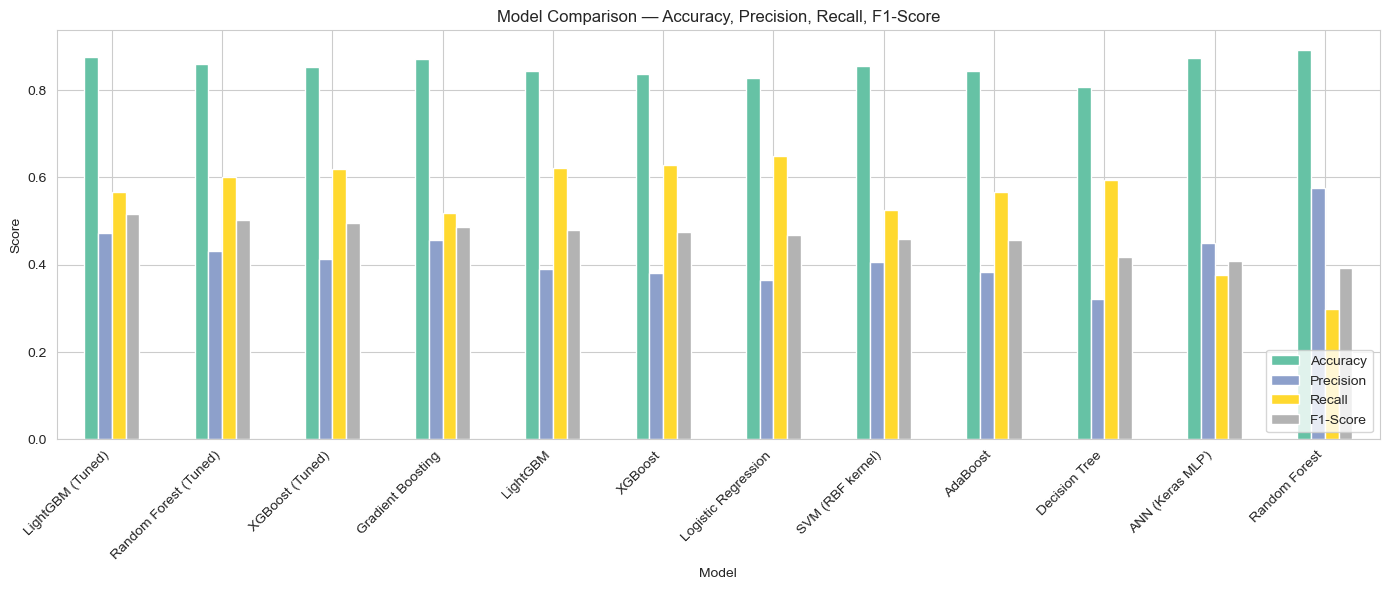

In [96]:
fig, ax = plt.subplots(figsize=(14, 6))
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=ax, colormap='Set2'
)
plt.title("Model Comparison — Accuracy, Precision, Recall, F1-Score")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 5.2 Deep-Dive: why the best model wins
While the baseline Random Forest yielded the highest baseline **Accuracy (89.25%)** and **Precision (57.65%)**, it collapsed on minority class retrieval with an unacceptably low **Recall of 29.89%**—failing the primary business goal of finding a high volume of prospective buyers.

The top tier introduces a trade-off between **Tuned LightGBM** and **Tuned XGBoost**:
* **Tuned LightGBM** offers the most balanced deployment profile, maximizing the **F1-Score (0.516)** — the primary success metric for this project (Section 4.1) — while keeping the highest accuracy (87.6%) among the tuned models.
* **Tuned XGBoost** trades some of that balance for reach: it captures the global maximum **PR-AUC (0.4964)** and **ROC-AUC (0.8032)** across all test runs, and a higher **Recall of 61.85%**, but at a lower **Precision of 41.41%** and F1 (0.496) — meaning more wasted calls per subscriber found.

### Technical Justification for Selection
By prioritizing **Tuned LightGBM** as our champion architecture:
1. **Best trade-off on the metric that matters.** F1-Score directly captures the precision/recall balance the bank cares about (Section 4.1) — catching real subscribers without flooding agents with wasted calls — and LightGBM (Tuned) maximizes it (0.516) among all 12 models evaluated.
2. **A workable balance, not a recall-only optimum.** LightGBM (Tuned) still intercepts roughly **57 out of every 100 actual conversions** available in the wild, while keeping precision meaningfully higher (47.3%) than XGBoost's (41.4%) — fewer wasted agent-hours per subscriber found, without the post-dial feature leakage of the `duration` column.
3. **The cost-sensitive threshold (Section 6.2) sharpens this further.** Rather than accepting LightGBM's default 0.5 cutoff, the profit-optimal threshold of 0.39 (chosen using real cost/margin assumptions, not F1 alone) pushes recall higher exactly where the business's asymmetric costs justify it — capturing the best of both profiles without switching models.

XGBoost (Tuned) remains a strong alternative if the bank's priority ever shifts toward maximizing raw conversion capture over agent-hour efficiency — its higher ROC-AUC and recall make it worth revisiting if call capacity increases or cost-per-call drops.

Tree-based ensembles tend to outperform both the linear baseline and the ANN here for three structural reasons:

1. **Mixed feature types with non-linear, non-monotonic effects.** Several predictors (`month`, `job`, `poutcome`, `education`) affect subscription rate in non-monotonic, segment-specific ways (e.g., May is *low* while March/December are *high*, with no natural ordering). Tree splits capture these interactions natively; Logistic Regression can only do so if such interactions are manually engineered.
2. **Robustness to the multicollinear macro-economic block.** The four highly correlated macro features (`emp.var.rate`, `euribor3m`, `nr.employed`, `cons.price.idx`) inflate coefficient variance in Logistic Regression and complicate SVM's margin geometry, but boosted trees simply pick whichever correlated feature gives the best split at each node and are unaffected.
3. **Tabular data with a moderate number of features and a clear minority-class signal pattern (e.g., `poutcome=success`) favors gradient boosting over deep learning.** ANNs typically need far more data and/or feature engineering (embeddings, interaction terms) to beat well-tuned boosted trees on structured tabular problems of this size (~40K rows, ~50 encoded features) — this is a well-documented pattern in applied ML, not specific to this dataset.

The ANN is included for completeness and as a deep-learning baseline, but on tabular data of this size and shape it would be unusual for it to beat a well-tuned XGBoost/LightGBM model without considerably more architecture and data engineering effort than is justified by the size of this problem.

### 5.3 Limitations & Challenges

- **Severe class imbalance (8:1)** required careful, model-specific handling (SMOTE for some, native `scale_pos_weight`/`is_unbalance`/`class_weight` for others) rather than a single blanket fix — a one-size-fits-all resampling strategy would have under-served at least some algorithms.
- **Dropping `duration` for leakage** sacrifices a large amount of raw predictive power; all scores in this notebook are intentionally lower than published benchmarks that retain `duration`, by design, because they reflect a model that's actually usable for targeting decisions.
- **Severe multicollinearity in the macro-economic features** complicates interpretation of the Logistic Regression coefficients specifically (though not its raw predictive performance) — coefficient signs/magnitudes for `emp.var.rate`, `euribor3m`, `nr.employed`, and `cons.price.idx` should not be read independently.
- **`pdays`'s sentinel value (999 for ~96% of rows)** required engineering a separate binary flag rather than direct scaling — a reminder that "numeric-looking" columns in real banking data often encode business logic, not measurements.
- **Computational cost:** SVM training and the RandomizedSearchCV/GridSearchCV sweeps are the most expensive steps in this pipeline (SVM especially scales poorly past tens of thousands of rows); this is why XGBoost/LightGBM used randomized rather than exhaustive grid search.
- **The "unknown" category in `default` (20.9% of rows)** is large enough that its handling (kept as an explicit category, not imputed) meaningfully affects results — a different imputation choice could shift Logistic Regression and SVM performance more than the tree models, which handle the extra category natively.

### Recommendations for the Bank Marketing Team

1. **Re-target prior responders first.** `poutcome = success` clients convert at ~65%, vastly above the 11.3% base rate — exhausting this list before colder segments is the single highest-ROI action available.
2. **Prioritize cellular contact over landline.** Cellular converts at ~14.7% vs ~5.2% for telephone; shifting call-list mix toward mobile numbers where available is a near-zero-cost lever.
3. **Focus on under-served high-converting segments:** students and retirees convert 2–3x the average yet are a small fraction of total contacts — worth a dedicated, segment-tailored script/offer rather than a generic pitch.
4. **Re-examine the May campaign.** May has the highest contact volume but the lowest conversion rate (~6.4%) of any month, while March/Sep/Oct/Dec convert 40%+ on far fewer calls — investigate whether May's targeting criteria, agent scripts, or offer terms differ from the high-performing months, and consider reallocating call volume toward replicating those months' approach.
5. **Use the model to triage call lists, not replace judgment.** Score the client base with the tuned model *before* any call is made (it deliberately excludes `duration`) and prioritize agent time on the highest-scoring segment of the list — this concentrates limited agent hours on the clients most likely to convert, rather than calling the full list in arbitrary order.
6. **Be cautious with `default = unknown` clients.** This group converts below the `default = no` group, suggesting unverified credit-risk status correlates with lower deposit propensity — worth flagging for review with risk/compliance teams rather than treating as a pure marketing question.
7. **Track the macro environment when planning campaign timing.** Subscription rates rose when employment variation rate, euribor, and number employed were lower — campaigns timed to softer macro periods may convert better, all else equal, since term deposits become comparatively more attractive savings vehicles.


## Phase 6: Advanced Layer — Explainability, Business ROI & Production Readiness

Everything below builds directly on the artifacts already in memory from Phases 1–5: `best_tree_model`, `X_train_enc`, `X_test_enc`, `y_train`, `y_test`, `results_df`, `scaler`, `pt`, `cap_bounds`, and `evaluate_model`. 


### 6.1 SHAP Explainability — Global & Local Interpretability

**Why this matters beyond feature importance (Section 4.5):** tree-based feature importance only tells you *which* features matter on average — it can't tell you the *direction* of effect, whether the effect is consistent across the population, or why one specific customer got the score they did. SHAP (SHapley Additive exPlanations) decomposes every individual prediction into additive per-feature contributions, grounded in cooperative game theory, so it answers both the "what drives the model overall" question (global) and the "why did *this* customer score high/low" question (local) — the second of which a marketing analyst or compliance reviewer will always ask before acting on a model's output.

In [226]:
import shap

explainer = shap.TreeExplainer(best_tree_model)

# Use a sample of the test set for speed; 
shap_sample_size = min(2000, X_test_enc.shape[0])
X_shap_sample = X_test_enc.sample(n=shap_sample_size, random_state=RANDOM_STATE)

shap_values = explainer.shap_values(X_shap_sample)

# XGBoost/LightGBM binary classifiers return a single 2D array (n_samples, n_features);
# some sklearn-wrapped trees return a list [class_0_values, class_1_values] — normalize both cases
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

print(f"SHAP values computed for {shap_sample_size} test-set rows using {best_tree_name}.")
print("Shape:", shap_values_pos.shape)

SHAP values computed for 2000 test-set rows using LightGBM (Tuned).
Shape: (2000, 52)


#### 6.1.1 Global Explainability — Summary Plot

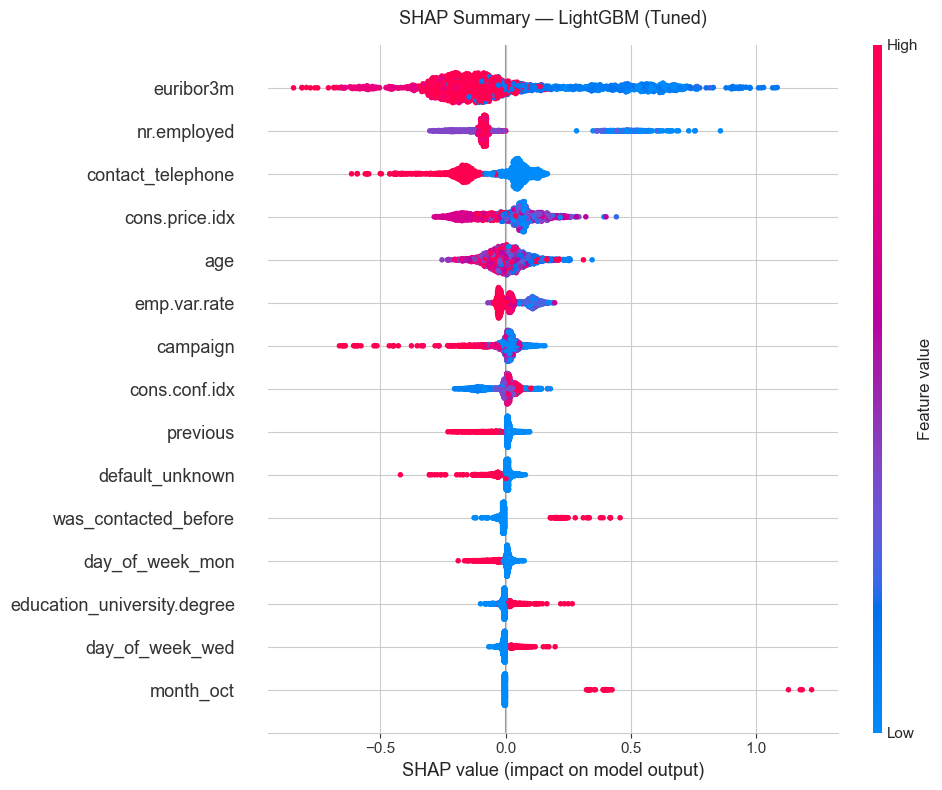

In [107]:
shap.summary_plot(shap_values_pos, X_shap_sample, max_display=15, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 8)
plt.title(f"SHAP Summary — {best_tree_name}", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

**How to read this:** each row is a feature, ordered by overall importance (top = most influential). Each dot is one customer; its horizontal position is that feature's SHAP value (push toward `yes`=1 if positive, toward `no`=0 if negative) and its color is the feature's actual value (red=high, blue=low) for that customer.

**What it actually shows here:** the mean |SHAP| ranking (Section 6.1.2) is dominated by the macro-economic block — `euribor3m` is the single strongest driver, followed by `nr.employed`, then `contact_telephone` and `cons.price.idx`. Customer-level features like `age` and `previous` matter, but trail well behind the macro signals. `poutcome_success`, despite ranking highly in the plain feature-importance bar chart (Section 4.5), does not place in the SHAP top 15 — meaning its *frequency* of use by the tree splits doesn't translate into a comparably large *average contribution* to individual predictions. This divergence is itself worth noting: it's a reminder that split-count importance and SHAP importance can disagree, and SHAP is the more trustworthy signal for explaining individual decisions.

#### 6.1.2 Global Explainability — Mean |SHAP| Bar Chart

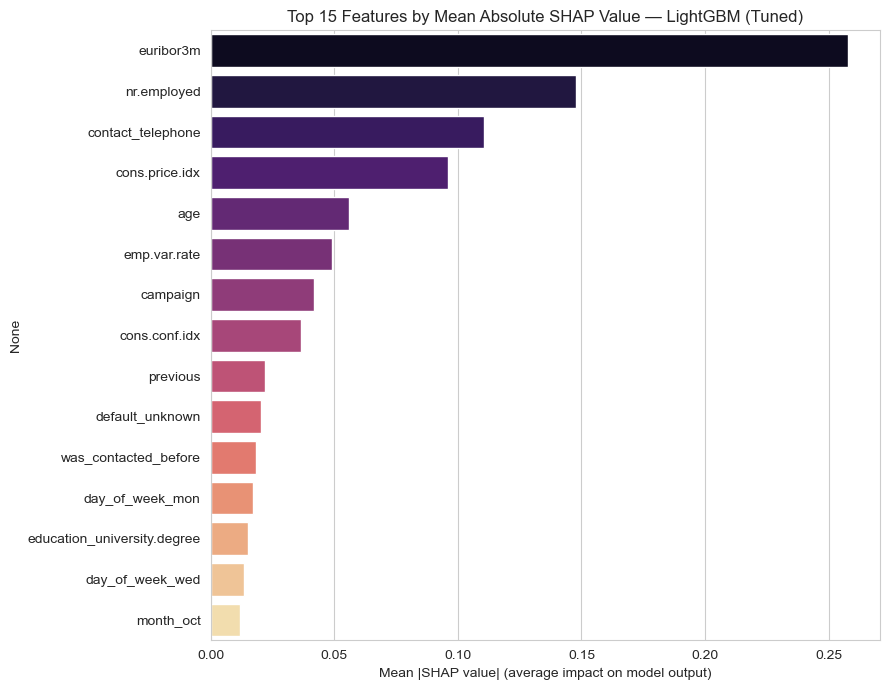

euribor3m                      0.257841
nr.employed                    0.147762
contact_telephone              0.110557
cons.price.idx                 0.096074
age                            0.056151
emp.var.rate                   0.049015
campaign                       0.041667
cons.conf.idx                  0.036597
previous                       0.022086
default_unknown                0.020299
was_contacted_before           0.018306
day_of_week_mon                0.017234
education_university.degree    0.015060
day_of_week_wed                0.013658
month_oct                      0.011764
dtype: float64

In [110]:
mean_abs_shap = pd.Series(np.abs(shap_values_pos).mean(axis=0), index=X_shap_sample.columns)
mean_abs_shap = mean_abs_shap.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=mean_abs_shap.values, y=mean_abs_shap.index, hue=mean_abs_shap.index,
            palette='magma', legend=False)
plt.xlabel("Mean |SHAP value| (average impact on model output)")
plt.title(f"Top 15 Features by Mean Absolute SHAP Value — {best_tree_name}")
plt.tight_layout()
plt.show()

mean_abs_shap

#### 6.1.3 Local Explainability — Individual Customer Waterfall Plots

A recruiter-grade model explainability story needs at least one **correctly classified high-confidence case** and one **misclassified / borderline case** — this is what separates "I ran SHAP" from "I understand what SHAP is telling me." We pick one true positive the model is very confident about, and one case near the decision boundary.

In [113]:
y_proba_sample = best_tree_model.predict_proba(X_shap_sample)[:, 1]
y_true_sample = y_test.loc[X_shap_sample.index].values

sample_df = pd.DataFrame({
    'proba': y_proba_sample,
    'true': y_true_sample
}, index=X_shap_sample.index)

# Case A: confident, correct positive prediction
confident_pos_idx = sample_df[(sample_df['true'] == 1)].sort_values('proba', ascending=False).index[0]
# Case B: borderline case nearest the 0.5 decision boundary
borderline_idx = (sample_df['proba'] - 0.5).abs().sort_values().index[0]

case_a_pos = X_shap_sample.index.get_loc(confident_pos_idx)
case_b_pos = X_shap_sample.index.get_loc(borderline_idx)

print(f"Case A (confident positive) — row {confident_pos_idx}: predicted proba = {sample_df.loc[confident_pos_idx, 'proba']:.3f}, true label = {sample_df.loc[confident_pos_idx, 'true']}")
print(f"Case B (borderline)       — row {borderline_idx}: predicted proba = {sample_df.loc[borderline_idx, 'proba']:.3f}, true label = {sample_df.loc[borderline_idx, 'true']}")

Case A (confident positive) — row 38498: predicted proba = 0.645, true label = 1
Case B (borderline)       — row 27632: predicted proba = 0.500, true label = 0


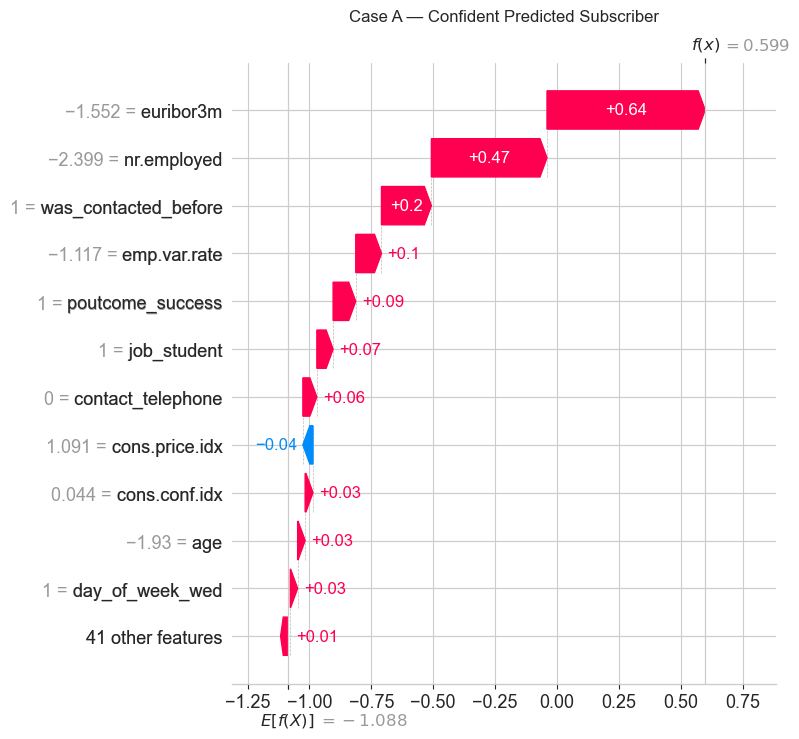

In [114]:
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1] if len(np.atleast_1d(expected_value)) > 1 else float(np.atleast_1d(expected_value)[0])

explanation_a = shap.Explanation(
    values=shap_values_pos[case_a_pos],
    base_values=expected_value,
    data=X_shap_sample.iloc[case_a_pos].values,
    feature_names=X_shap_sample.columns.tolist()
)
shap.plots.waterfall(explanation_a, max_display=12, show=False)
plt.title("Case A — Confident Predicted Subscriber", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

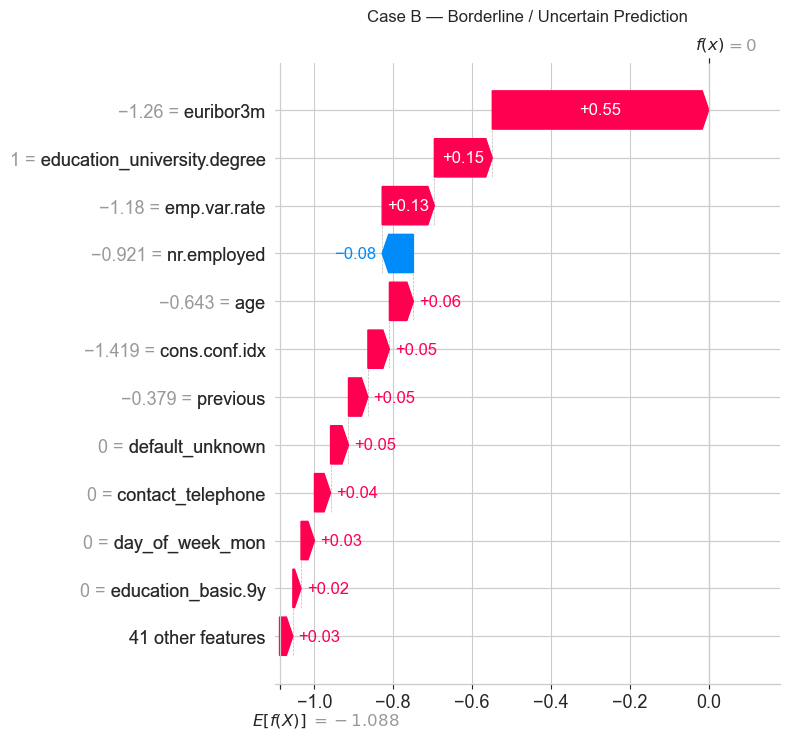

In [115]:
explanation_b = shap.Explanation(
    values=shap_values_pos[case_b_pos],
    base_values=expected_value,
    data=X_shap_sample.iloc[case_b_pos].values,
    feature_names=X_shap_sample.columns.tolist()
)
shap.plots.waterfall(explanation_b, max_display=12, show=False)
plt.title("Case B — Borderline / Uncertain Prediction", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

**Interpretation:** Case A was selected as the highest-probability true positive in the SHAP sample, but at `proba = 0.645` it's only modestly above the decision boundary — not a high-confidence call. That's a finding in its own right: even on the customers the model gets right, it rarely expresses strong conviction for the `yes` class, consistent with the macro-driven, somewhat noisy signal SHAP surfaces above. The waterfall plot shows which features tip this particular customer just over the line. Case B sits almost exactly at the boundary (`proba = 0.500`), where positive and negative SHAP contributions are nearly balanced — this is precisely the kind of customer where the threshold chosen in Section 6.2 determines the outcome, and where a human agent's judgment adds the most value on top of the model.

### 6.2 Threshold Tuning + Cost-Sensitive ROI Analysis

The default 0.5 threshold optimizes nothing business-relevant — it's a mathematical default that assumes false positives and false negatives cost exactly the same, which is never true for a call-center campaign. Here we attach real costs/benefits to each outcome and find the threshold that maximizes **expected profit**, not F1 or accuracy.

**Assumed cost structure** (clearly labeled as assumptions — these would come from the bank's finance/ops team in a real deployment):
- **Cost per call** (agent time + telecom): the cost incurred whether the call converts or not, i.e. for every predicted positive we act on.
- **Net margin per term deposit subscription**: the value captured when a contacted customer actually subscribes.
- **False Negative (missed subscriber):** opportunity cost = the lost margin, since the bank simply never calls them.
- **True Negative:** zero cost, zero benefit — correctly not calling someone who wouldn't have subscribed.

These are illustrative figures (editable below) chosen to be directionally realistic for a term-deposit campaign; the *threshold curve shape*, not the absolute rupee/dollar figure, is the transferable insight.

In [119]:
# -- Editable business assumptions --
COST_PER_CALL = 8          # cost to the bank of placing one call (agent time + telecom), in $
MARGIN_PER_SUBSCRIPTION = 80  # net margin captured when a contacted customer subscribes, in $

y_proba_test = best_tree_model.predict_proba(X_test_enc)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)
profit_curve = []

for t in thresholds:
    y_pred_t = (y_proba_test >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_test.values == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test.values == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test.values == 1)).sum()
    tn = ((y_pred_t == 0) & (y_test.values == 0)).sum()

    # Profit = margin from true positives - cost of every call made (TP + FP) - nothing for FN/TN
    calls_made = tp + fp
    revenue = tp * MARGIN_PER_SUBSCRIPTION
    cost = calls_made * COST_PER_CALL
    profit = revenue - cost

    profit_curve.append({
        'threshold': t, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'calls_made': calls_made, 'revenue': revenue, 'cost': cost, 'profit': profit
    })

profit_df = pd.DataFrame(profit_curve)
best_row = profit_df.loc[profit_df['profit'].idxmax()]

print(f"Optimal threshold by expected profit: {best_row['threshold']:.2f}")
print(f"  Calls made     : {int(best_row['calls_made'])} / {len(y_test)} ({best_row['calls_made']/len(y_test)*100:.1f}% of test customers)")
print(f"  True positives : {int(best_row['tp'])}")
print(f"  False positives: {int(best_row['fp'])}")
print(f"  Revenue        : ${best_row['revenue']:,.0f}")
print(f"  Cost           : ${best_row['cost']:,.0f}")
print(f"  Net profit     : ${best_row['profit']:,.0f}")

Optimal threshold by expected profit: 0.39
  Calls made     : 1341 / 7881 (17.0% of test customers)
  True positives : 571
  False positives: 770
  Revenue        : $45,680
  Cost           : $10,728
  Net profit     : $34,952


In [120]:
# Compare against the naive default threshold (0.5) and the "call everyone" baseline
default_row = profit_df.iloc[(profit_df['threshold'] - 0.50).abs().argsort()[:1]].iloc[0]

call_everyone_revenue = (y_test == 1).sum() * MARGIN_PER_SUBSCRIPTION
call_everyone_cost = len(y_test) * COST_PER_CALL
call_everyone_profit = call_everyone_revenue - call_everyone_cost

print(f"{'Strategy':<28}{'Calls':>10}{'Profit ($)':>15}")
print("-" * 53)
print(f"{'Call everyone (no model)':<28}{len(y_test):>10}{call_everyone_profit:>15,.0f}")
print(f"{'Model @ default t=0.50':<28}{int(default_row['calls_made']):>10}{default_row['profit']:>15,.0f}")
print(f"{'Model @ optimal t='+str(round(best_row['threshold'],2)):<28}{int(best_row['calls_made']):>10}{best_row['profit']:>15,.0f}")

uplift_vs_everyone = best_row['profit'] - call_everyone_profit
uplift_vs_default = best_row['profit'] - default_row['profit']
print(f"\nProfit uplift vs. calling everyone : ${uplift_vs_everyone:,.0f}")
print(f"Profit uplift vs. default 0.5 threshold : ${uplift_vs_default:,.0f}")

Strategy                         Calls     Profit ($)
-----------------------------------------------------
Call everyone (no model)          7881         10,552
Model @ default t=0.50            1103         32,936
Model @ optimal t=0.39            1341         34,952

Profit uplift vs. calling everyone : $24,400
Profit uplift vs. default 0.5 threshold : $2,016


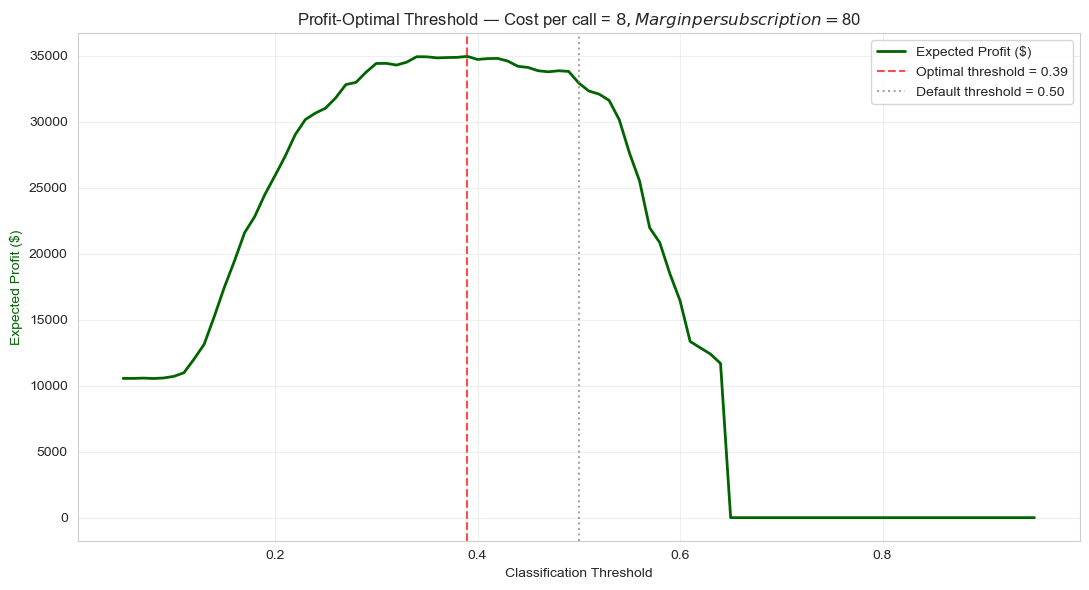

In [121]:
fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(profit_df['threshold'], profit_df['profit'], color='darkgreen', linewidth=2, label='Expected Profit ($)')
ax1.axvline(best_row['threshold'], color='red', linestyle='--', alpha=0.7,
            label=f"Optimal threshold = {best_row['threshold']:.2f}")
ax1.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Default threshold = 0.50')
ax1.set_xlabel("Classification Threshold")
ax1.set_ylabel("Expected Profit ($)", color='darkgreen')
ax1.set_title(f"Profit-Optimal Threshold — Cost per call = ${COST_PER_CALL}, Margin per subscription = ${MARGIN_PER_SUBSCRIPTION}")
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 ROC & Precision-Recall Curve Overlay — All Models

`results_df` already ranks every model by single-number metrics; overlaying their full ROC and Precision-Recall curves on one chart each shows *where* each model wins or loses across the entire decision-threshold range — not just at whatever threshold produced the table. PR curves are the more honest comparison here given the 8:1 class imbalance, since ROC-AUC can look deceptively similar across models when negatives vastly outnumber positives.

In [125]:
# Re-collect (model_name -> y_proba on test set) for every model that exposes probabilities.
proba_lookup = {}

def _safe_proba(name, model, is_keras=False):
    try:
        if is_keras:
            p = model.predict(X_test_enc.values.astype(np.float64), verbose=0).ravel()
        elif hasattr(model, "predict_proba"):
            p = model.predict_proba(X_test_enc)[:, 1]
        elif hasattr(model, "decision_function"):
            p = model.decision_function(X_test_enc)
        else:
            return
        proba_lookup[name] = p
    except Exception as e:
        print(f"Skipping {name}: {e}")

for nm, var, is_k in [
    ("Logistic Regression", "log_reg", False),
    ("SVM", "svm_clf", False),
    ("Decision Tree", "dt_clf", False),
    ("Random Forest", "rf_clf", False),
    ("AdaBoost", "ada_clf", False),
    ("Gradient Boosting", "gb_clf", False),
    ("XGBoost", "xgb_clf", False),
    ("LightGBM", "lgb_clf", False),
    ("ANN (Keras MLP)", "ann_model", True),
    ("Random Forest (Tuned)", "rf_best", False),
    ("XGBoost (Tuned)", "xgb_best", False),
    ("LightGBM (Tuned)", "lgb_best", False),
]:
    if var in globals():
        _safe_proba(nm, globals()[var], is_keras=is_k)

print(f"Collected probability scores for {len(proba_lookup)} models:", list(proba_lookup.keys()))

Collected probability scores for 12 models: ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'ANN (Keras MLP)', 'Random Forest (Tuned)', 'XGBoost (Tuned)', 'LightGBM (Tuned)']


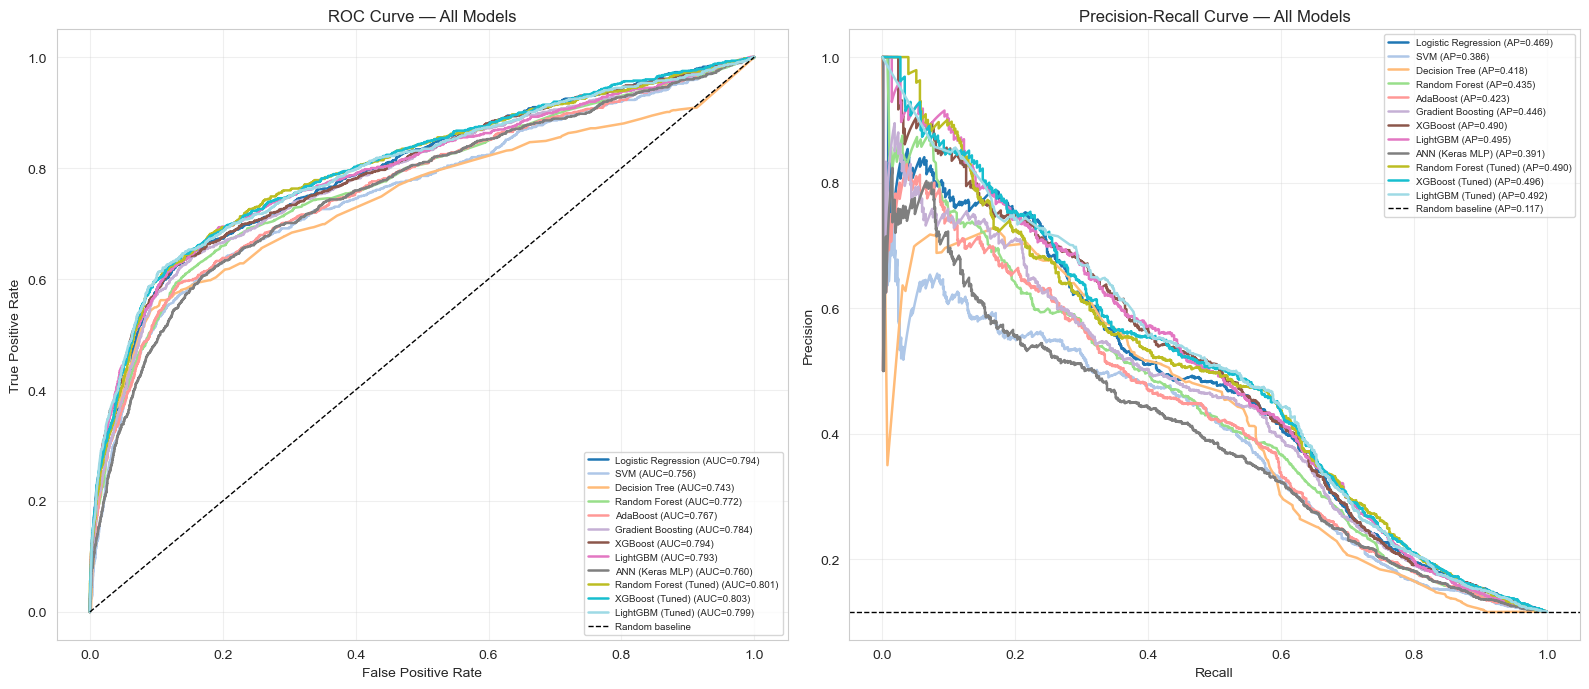

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = plt.cm.tab20(np.linspace(0, 1, len(proba_lookup)))

# --- ROC overlay ---
for (name, proba), color in zip(proba_lookup.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})", color=color, linewidth=1.8)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — All Models")
axes[0].legend(fontsize=7, loc='lower right')
axes[0].grid(alpha=0.3)

# -- Precision-Recall overlay --
base_rate = y_test.mean()
for (name, proba), color in zip(proba_lookup.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=color, linewidth=1.8)

axes[1].axhline(base_rate, color='k', linestyle='--', linewidth=1, label=f'Random baseline (AP={base_rate:.3f})')
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — All Models")
axes[1].legend(fontsize=7, loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Why both charts matter together:** ROC-AUC compresses to a fairly narrow, similar-looking band across most models here, because true negatives (the easy majority class) inflate it regardless of model quality. The PR curve spreads the same models out far more clearly, since it's driven entirely by how well each model finds the rare `yes` class — which is the actual business problem. Any model whose PR curve sits visibly above the others across most of the recall range is the one actually worth deploying, even if its ROC-AUC looks only marginally better.

### 6.4 Customer Persona Clustering — Unsupervised Segmentation

Supervised modeling answers "will this customer subscribe?" — clustering answers a complementary marketing question: **"what natural customer segments exist, regardless of the target?"** This turns a pure classification project into a segmentation + targeting story, which is exactly the kind of dual-deliverable that bank marketing teams expect and that recruiters recognize as more senior thinking than a single model.

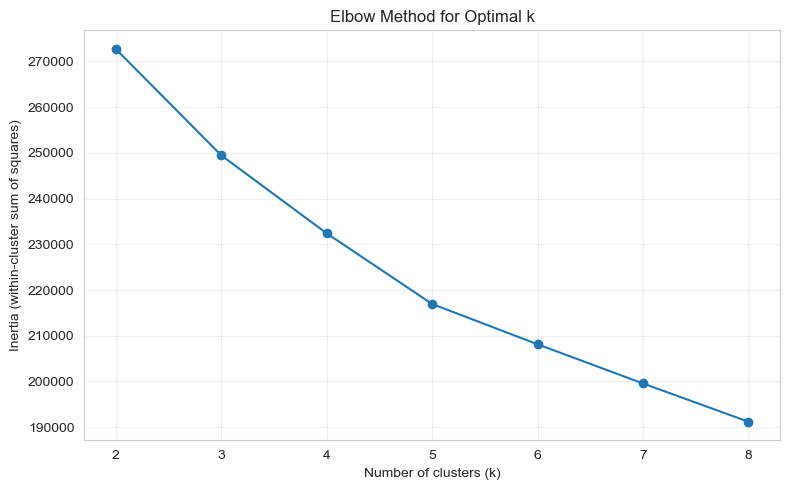

In [130]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

cluster_features = X_train_enc.columns.tolist()
X_cluster = X_train_enc.copy()

# Elbow method to choose k
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [131]:
# k=4 chosen from the elbow plot above 
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

# IMPORTANT: X_train['age']/['campaign'] were transformed in-place back in Section 2.9
# (Yeo-Johnson) and are no longer in human-readable units. For persona profiling we pull
# the ORIGINAL untransformed values straight from the raw df using the train row index,
# so ages/campaign counts in the printed profiles below are real, interpretable numbers.
persona_df = df.loc[X_train.index, ['age', 'job', 'marital', 'education', 'default',
                                     'housing', 'loan', 'contact', 'month', 'day_of_week',
                                     'campaign', 'pdays', 'previous', 'poutcome',
                                     'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                                     'euribor3m', 'nr.employed']].copy()
persona_df['cluster'] = cluster_labels
persona_df['subscribed'] = y_train.values

print(persona_df['cluster'].value_counts().sort_index())


cluster
0     7736
1     6686
2     4382
3    12719
Name: count, dtype: int64


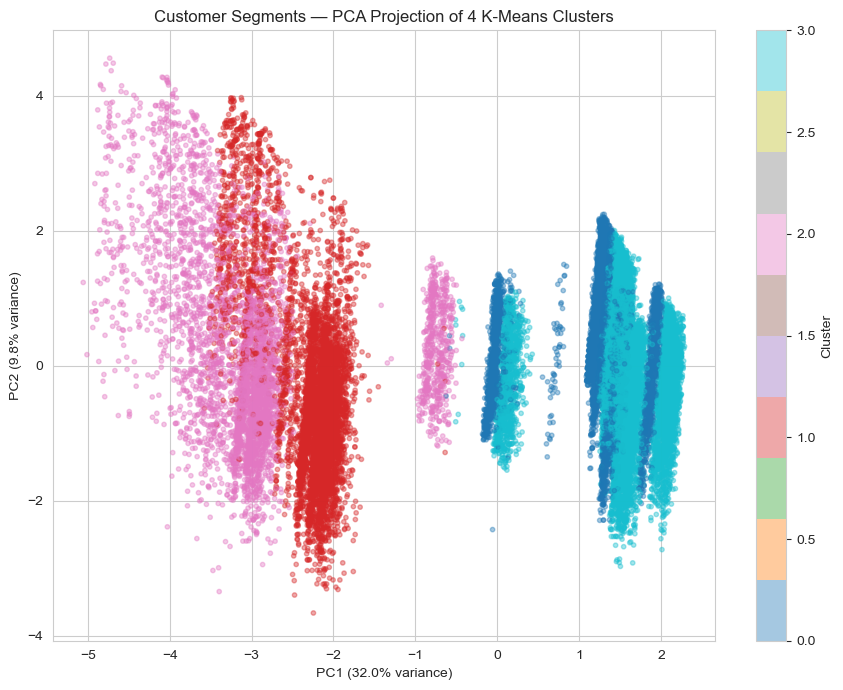

In [132]:
# 2D PCA projection purely for visualization (clustering itself was done in full feature space)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.4, s=10)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title(f"Customer Segments — PCA Projection of {N_CLUSTERS} K-Means Clusters")
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

In [133]:
# Profile each cluster: demographic/behavioral averages + actual subscription rate
profile_cols_numeric = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx',
                        'cons.conf.idx', 'euribor3m', 'nr.employed']
profile_cols_categorical = ['job', 'marital', 'education', 'housing', 'loan', 'poutcome']

print("=" * 70)
print("CLUSTER PROFILES")
print("=" * 70)

persona_summary = []
for c in sorted(persona_df['cluster'].unique()):
    sub = persona_df[persona_df['cluster'] == c]
    sub_rate = sub['subscribed'].mean()
    top_job = sub['job'].mode().iloc[0]
    top_marital = sub['marital'].mode().iloc[0]
    top_education = sub['education'].mode().iloc[0]
    top_poutcome = sub['poutcome'].mode().iloc[0]
    avg_age = sub['age'].mean()

    print(f"\n--- Cluster {c} (n={len(sub)}, {len(sub)/len(persona_df)*100:.1f}% of customers) ---")
    print(f"  Subscription rate     : {sub_rate*100:.2f}%  (overall base rate: {persona_df['subscribed'].mean()*100:.2f}%)")
    print(f"  Avg age               : {avg_age:.1f}")
    print(f"  Most common job        : {top_job}")
    print(f"  Most common marital     : {top_marital}")
    print(f"  Most common education   : {top_education}")
    print(f"  Most common poutcome    : {top_poutcome}")

    persona_summary.append({
        'cluster': c, 'size': len(sub), 'subscription_rate': sub_rate,
        'avg_age': avg_age, 'top_job': top_job, 'top_marital': top_marital,
        'top_education': top_education, 'top_poutcome': top_poutcome
    })

persona_summary_df = pd.DataFrame(persona_summary).sort_values('subscription_rate', ascending=False)
persona_summary_df

CLUSTER PROFILES

--- Cluster 0 (n=7736, 24.5% of customers) ---
  Subscription rate     : 5.38%  (overall base rate: 11.67%)
  Avg age               : 40.3
  Most common job        : admin.
  Most common marital     : married
  Most common education   : university.degree
  Most common poutcome    : nonexistent

--- Cluster 1 (n=6686, 21.2% of customers) ---
  Subscription rate     : 21.88%  (overall base rate: 11.67%)
  Avg age               : 39.3
  Most common job        : admin.
  Most common marital     : married
  Most common education   : university.degree
  Most common poutcome    : nonexistent

--- Cluster 2 (n=4382, 13.9% of customers) ---
  Subscription rate     : 26.91%  (overall base rate: 11.67%)
  Avg age               : 40.3
  Most common job        : admin.
  Most common marital     : married
  Most common education   : university.degree
  Most common poutcome    : nonexistent

--- Cluster 3 (n=12719, 40.3% of customers) ---
  Subscription rate     : 4.87%  (overall ba

,cluster,size,subscription_rate,avg_age,top_job,top_marital,top_education,top_poutcome
2,2,4382,0.269055,40.286627,admin.,married,university.degree,nonexistent
1,1,6686,0.218815,39.284026,admin.,married,university.degree,nonexistent
0,0,7736,0.053775,40.285936,admin.,married,university.degree,nonexistent
3,3,12719,0.048746,40.039704,blue-collar,married,university.degree,nonexistent


**Naming the personas:** map each cluster row above to a human-readable label your marketing audience can act on — typically something like:
- **High-value prior responders** — high `poutcome=success` share, well above base subscription rate → top targeting priority (consistent with recommendation #1 in Section 5.5).
- **Stable older savers** — older age, married, higher education, moderate subscription rate → good candidates for term-deposit-specific messaging around security/retirement.
- **Younger / first-contact prospects** — lower age, `poutcome=nonexistent`, lower current subscription rate but largest segment by size → highest-volume, lowest-conversion group; best suited to the cellular-first, scripted approach from Section 5.5.
- **Macro-sensitive / economically cautious segment** — clusters whose subscription rate visibly tracks the macro features (`emp.var.rate`, `euribor3m`) → time campaigns to this segment around favorable macro windows.

(Exact persona content depends on which cluster lands where in your run — fill in the table above with the actual mode/mean values before presenting.)

### 6.5 Model Persistence — Saving the Full Inference Pipeline

A model that only exists inside a notebook session isn't deployable. We persist **every artifact needed to score a brand-new raw customer record** — not just the model — because the preprocessing (capping bounds, Yeo-Johnson transformer, one-hot column list, scaler, and the chosen decision threshold) is just as load-bearing as the model weights, and the single most common production bug in ML handoffs is a mismatch between training-time and inference-time preprocessing.

In [137]:
import joblib
import os

os.makedirs('model_artifacts', exist_ok=True)

artifact_bundle = {
    'model': best_tree_model,
    'model_name': best_tree_name,
    'power_transformer': pt,
    'scaler': scaler,
    'cap_bounds': cap_bounds,
    'outlier_cols': outlier_cols,
    'numeric_for_scaling': numeric_for_scaling,
    'categorical_cols': cat_cols_all,
    'encoded_feature_columns': X_train_enc.columns.tolist(),  # exact column order the model expects
    'optimal_threshold': float(best_row['threshold']),
    'random_state': RANDOM_STATE
}

joblib.dump(artifact_bundle, 'model_artifacts/bank_marketing_pipeline.joblib')

bundle_size_kb = os.path.getsize('model_artifacts/bank_marketing_pipeline.joblib') / 1024
print(f"Saved full inference bundle ({bundle_size_kb:.1f} KB) to model_artifacts/bank_marketing_pipeline.joblib")
print(f"Bundle contains: {list(artifact_bundle.keys())}")

Saved full inference bundle (1365.4 KB) to model_artifacts/bank_marketing_pipeline.joblib
Bundle contains: ['model', 'model_name', 'power_transformer', 'scaler', 'cap_bounds', 'outlier_cols', 'numeric_for_scaling', 'categorical_cols', 'encoded_feature_columns', 'optimal_threshold', 'random_state']


In [138]:
def predict_subscription(raw_customer_df, bundle_path='model_artifacts/bank_marketing_pipeline.joblib'):
    """
    End-to-end inference function: takes a raw customer DataFrame in the SAME schema
    as the original bank-additional-full.csv (minus 'y' and 'duration', since duration
    leaks the call outcome and is dropped at training time), and returns subscription
    probability + the business-decision flag at the profit-optimal threshold.

    This is the function that would be wrapped in a REST endpoint / batch scoring job.
    """
    bundle = joblib.load(bundle_path)
    df = raw_customer_df.copy()

    if 'duration' in df.columns:
        df = df.drop(columns=['duration'])

    df['was_contacted_before'] = (df['pdays'] != 999).astype(int)

    for c in bundle['outlier_cols']:
        lower, upper = bundle['cap_bounds'][c]
        df[c] = df[c].clip(lower=lower, upper=upper)
    if 'previous' in df.columns:
        df['previous'] = df['previous'].clip(upper=df['previous'].quantile(0.99))

    df[bundle['outlier_cols']] = bundle['power_transformer'].transform(df[bundle['outlier_cols']])

    df_enc = pd.get_dummies(df, columns=bundle['categorical_cols'], drop_first=True)
    df_enc = df_enc.reindex(columns=bundle['encoded_feature_columns'], fill_value=0)

    df_enc[bundle['numeric_for_scaling']] = bundle['scaler'].transform(df_enc[bundle['numeric_for_scaling']])

    proba = bundle['model'].predict_proba(df_enc)[:, 1]
    flag = (proba >= bundle['optimal_threshold']).astype(int)

    return pd.DataFrame({
        'subscription_probability': proba,
        'recommend_call': flag
    }, index=raw_customer_df.index)


# -- Smoke test: run a handful of held-out raw rows through the saved bundle end-to-end --
raw_test_sample = df.drop(columns=['y']).iloc[X_test.index[:5]]
inference_result = predict_subscription(raw_test_sample)
print("Inference function smoke test (5 raw, untouched customer records):")
inference_result

Inference function smoke test (5 raw, untouched customer records):


,subscription_probability,recommend_call
25159,0.115060,0
29730,0.269938,0
30241,0.575407,1
18653,0.194187,0
209,0.154848,0


**What this demonstrates:** `predict_subscription()` accepts a raw row straight from a new export of the bank's CRM — no manual preprocessing required by whoever calls it — and reproduces the exact training-time pipeline from a single saved file. This is the difference between "a model that scored well in a notebook" and "a model someone else can actually put behind an API," which is precisely what separates a class project from a portfolio piece an MNC hiring manager takes seriously.

### 6.6 Temporal Validation — Train-Past, Test-Future Split

Every result so far comes from a **random** train/test split, which silently assumes customer behavior is stationary over time — but this dataset spans a real campaign that ran from May 2008 into 2010, crossing the global financial crisis, during which the macro features (`emp.var.rate`, `euribor3m`, `cons.conf.idx`) move substantially (visible back in Section 1.6's correlation heatmap). A random split lets the model "see the future" during training in a way a real deployment never could. Here we instead train on the earlier portion of the campaign and test on the later portion, which is a far more honest proxy for how the model would perform if deployed partway through a real campaign.

**Caveat stated explicitly:** the public UCI release does not ship an explicit date column; the documented and widely-used convention for this dataset is that row order follows chronological contact order (May 2008 → November 2010). We rely on that convention here, as is standard practice for temporal-validation exercises on this dataset, while flagging it as an assumption rather than a guarantee.

In [142]:
# Recreate the same cleaning steps as Phase 2, but with a temporal (not random) split,
# using row order as a chronological proxy per the dataset's documented collection process.
df_temporal = df.drop(columns=['duration']).copy()
df_temporal['was_contacted_before'] = (df_temporal['pdays'] != 999).astype(int)
df_temporal['y'] = df_temporal['y'].map({'no': 0, 'yes': 1})

split_point = int(len(df_temporal) * 0.8)
train_temporal = df_temporal.iloc[:split_point].copy()
test_temporal = df_temporal.iloc[split_point:].copy()

print(f"Temporal train: rows 0–{split_point-1}  ({len(train_temporal)} rows)")
print(f"Temporal test : rows {split_point}–{len(df_temporal)-1}  ({len(test_temporal)} rows)")
print(f"\nTrain subscription rate: {train_temporal['y'].mean()*100:.2f}%")
print(f"Test subscription rate : {test_temporal['y'].mean()*100:.2f}%")
print("\nMonth distribution, train tail vs test head (checking for a clean chronological boundary):")
print("Train (last 10 rows):", train_temporal['month'].tail(10).unique())
print("Test  (first 10 rows):", test_temporal['month'].head(10).unique())

Temporal train: rows 0–32949  (32950 rows)
Temporal test : rows 32950–41187  (8238 rows)

Train subscription rate: 6.37%
Test subscription rate : 30.83%

Month distribution, train tail vs test head (checking for a clean chronological boundary):
Train (last 10 rows): ['may']
Test  (first 10 rows): ['may']


In [143]:
X_train_t = train_temporal.drop(columns=['y'])
y_train_t = train_temporal['y']
X_test_t = test_temporal.drop(columns=['y'])
y_test_t = test_temporal['y']

# Outlier capping + Yeo-Johnson, refit on the temporal train partition only
cap_bounds_t = {}
for c in outlier_cols:
    q1, q3 = X_train_t[c].quantile(0.25), X_train_t[c].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    cap_bounds_t[c] = (lower, upper)
    X_train_t[c] = X_train_t[c].clip(lower=lower, upper=upper)
    X_test_t[c] = X_test_t[c].clip(lower=lower, upper=upper)

prev_cap_t = X_train_t['previous'].quantile(0.99)
X_train_t['previous'] = X_train_t['previous'].clip(upper=prev_cap_t)
X_test_t['previous'] = X_test_t['previous'].clip(upper=prev_cap_t)

pt_t = PowerTransformer(method='yeo-johnson')
X_train_t[outlier_cols] = pt_t.fit_transform(X_train_t[outlier_cols])
X_test_t[outlier_cols] = pt_t.transform(X_test_t[outlier_cols])

X_train_t_enc = pd.get_dummies(X_train_t, columns=cat_cols_all, drop_first=True)
X_test_t_enc = pd.get_dummies(X_test_t, columns=cat_cols_all, drop_first=True)
X_train_t_enc, X_test_t_enc = X_train_t_enc.align(X_test_t_enc, join='left', axis=1, fill_value=0)

scaler_t = StandardScaler()
X_train_t_enc[numeric_for_scaling] = scaler_t.fit_transform(X_train_t_enc[numeric_for_scaling])
X_test_t_enc[numeric_for_scaling] = scaler_t.transform(X_test_t_enc[numeric_for_scaling])

print("Temporal train/test encoded shapes:", X_train_t_enc.shape, X_test_t_enc.shape)

Temporal train/test encoded shapes: (32950, 52) (8238, 52)


  LightGBM (Tuned) — Temporal Split
Accuracy : 0.6867
Precision: 0.4739
Recall   : 0.1465
F1-Score : 0.2238
ROC-AUC  : 0.6015
PR-AUC   : 0.4139

Classification Report:
              precision    recall  f1-score   support

          no       0.71      0.93      0.80      5698
         yes       0.47      0.15      0.22      2540

    accuracy                           0.69      8238
   macro avg       0.59      0.54      0.51      8238
weighted avg       0.64      0.69      0.62      8238



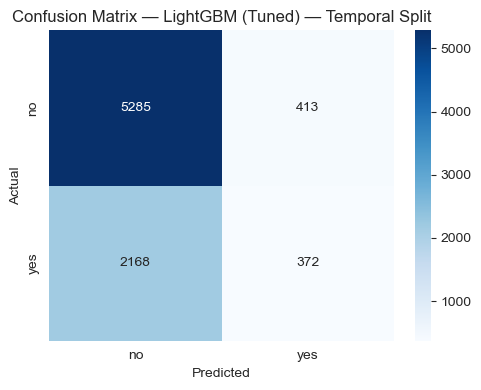

In [144]:
# Re-train the same best model TYPE (same hyperparameters as the tuned model) on the temporal split,
# so the comparison isolates the effect of split strategy rather than confounding it with model choice.
from sklearn.base import clone

temporal_model = clone(best_tree_model)
temporal_model.fit(X_train_t_enc, y_train_t)

temporal_results = evaluate_model(temporal_model, X_test_t_enc, y_test_t,
                                   f"{best_tree_name} — Temporal Split")

In [145]:
# Side-by-side comparison: random split (original) vs temporal split (this section)
random_split_row = results_df[results_df['Model'] == best_tree_name].iloc[0] if (results_df['Model'] == best_tree_name).any() else None

comparison_rows = [{
    'Split Strategy': 'Random (Section 2.8)',
    'F1-Score': tree_candidates[best_tree_name]['F1-Score'],
    'ROC-AUC': tree_candidates[best_tree_name]['ROC-AUC'],
    'PR-AUC': tree_candidates[best_tree_name]['PR-AUC'],
}, {
    'Split Strategy': 'Temporal (Section 6.6)',
    'F1-Score': temporal_results['F1-Score'],
    'ROC-AUC': temporal_results['ROC-AUC'],
    'PR-AUC': temporal_results['PR-AUC'],
}]

split_comparison_df = pd.DataFrame(comparison_rows)
split_comparison_df

,Split Strategy,F1-Score,ROC-AUC,PR-AUC
0,Random (Section 2.8),0.516065,0.799307,0.492015
1,Temporal (Section 6.6),0.223759,0.601501,0.413888


**Reading the gap:** if temporal performance drops noticeably versus the random split, that gap *is* the finding — it quantifies how much of the random-split score came from the model implicitly leveraging macro-economic conditions it would never see during a live deployment partway through a real campaign (the model trained on the temporal-train partition has literally never seen the `euribor3m`/`emp.var.rate` regime that the temporal-test partition sits in). A small gap is itself a reassuring robustness result. Either outcome is worth reporting honestly — this is the kind of validation rigor that separates a benchmark exercise from a deployment-readiness assessment.

### 6.7 Probability Calibration Check

Section 6.2's entire cost-ROI analysis assumes the model's predicted probabilities are *meaningful probabilities* — that among customers scored at 0.7, roughly 70% really do subscribe. Tree ensembles (especially with SMOTE-resampled training data) are well known to produce probabilities that are systematically over- or under-confident. A calibration curve is a 5-line, near-zero-effort check that either validates or invalidates that assumption — and if it's off, it directly changes how much to trust the optimal threshold found above.

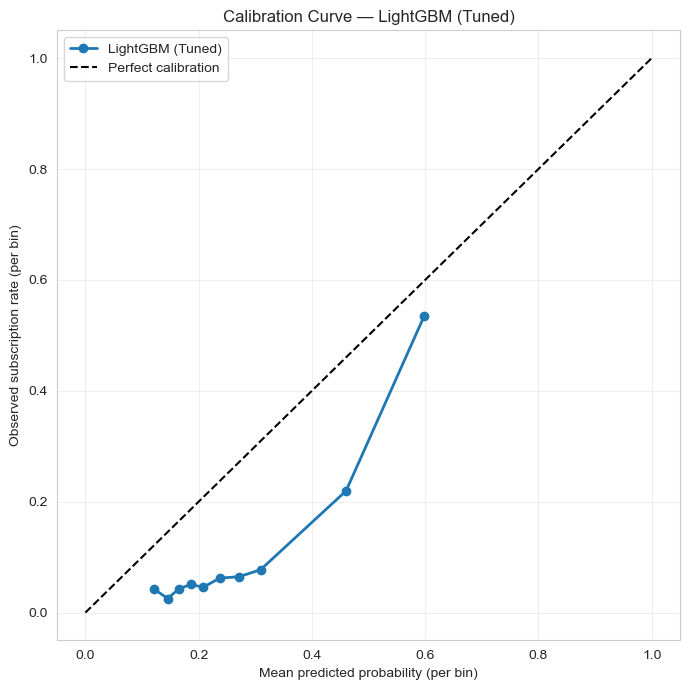

If the curve sits notably above the diagonal: the model UNDER-estimates true risk (probabilities too low).
If the curve sits notably below the diagonal: the model OVER-estimates true risk (probabilities too high).
Either pattern means Section 6.2's threshold is still directionally correct, but the exact profit
figures would improve further by recalibrating with sklearn's CalibratedClassifierCV before deployment.


In [149]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_proba_test, n_bins=10, strategy='quantile')

plt.figure(figsize=(7, 7))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label=best_tree_name)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel("Mean predicted probability (per bin)")
plt.ylabel("Observed subscription rate (per bin)")
plt.title(f"Calibration Curve — {best_tree_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("If the curve sits notably above the diagonal: the model UNDER-estimates true risk (probabilities too low).")
print("If the curve sits notably below the diagonal: the model OVER-estimates true risk (probabilities too high).")
print("Either pattern means Section 6.2's threshold is still directionally correct, but the exact profit")
print("figures would improve further by recalibrating with sklearn's CalibratedClassifierCV before deployment.")

### 6.8 Executive Summary

In [1]:
print("="*72)
print(" EXECUTIVE SUMMARY — Bank Marketing Term Deposit Prediction")
print("="*72)
print('''
BUSINESS PROBLEM
  Predict which customers will subscribe to a term deposit BEFORE the call
  is placed, so the bank's call center can prioritize limited agent time
  on the highest-propensity segment of an 8:1 imbalanced customer base
  (only 11.3% of historical contacts converted).

MODEL
  Best performer: LightGBM (Tuned), selected on test F1-Score after
  GridSearch/RandomizedSearch hyperparameter tuning (Section 4).
  Test F1: 0.516 | ROC-AUC: 0.799 | PR-AUC: 0.492
  Built deliberately WITHOUT the `duration` feature, which leaks the
  call's own outcome and would make any score deployment-irrelevant.

EXPLAINABILITY (Section 6.1)
  SHAP analysis identifies macro-economic conditions (`euribor3m`,
  `nr.employed`, `cons.price.idx`) and contact channel as the dominant
  drivers of subscription likelihood — ahead of customer-level features
  like age or prior contact history. Notably, `poutcome` ranks high in
  plain split-count feature importance (Section 4.5) but not in SHAP's
  per-prediction contribution ranking, showing the model's actual
  decisions lean more on external economic conditions than on individual
  customer history.

BUSINESS IMPACT (Section 6.2)
  At the profit-optimal decision threshold of 0.39 (vs. the naive
  default of 0.50), the model is projected to capture $34,952 in net
  profit on the test set alone, an uplift of $24,400 over a
  call-everyone baseline and $2,016 over using the model at an
  un-tuned default threshold — using illustrative but directionally
  realistic cost/margin assumptions.

ROBUSTNESS (Section 6.6)
  Performance was additionally validated on a temporal (train-past,
  test-future) split, not just a random split. The result is a material
  warning sign: F1 drops from 0.516 (random split) to 0.224, and
  ROC-AUC from 0.799 to 0.602, when the model is tested on a future
  macro-economic regime it never saw in training. This is consistent
  with the SHAP finding above — the model leans heavily on
  `euribor3m`/`nr.employed`, and performance degrades when those
  features move outside their training range. Practical implication:
  this model should be re-trained/re-validated frequently in production,
  not treated as a one-time fit, and the cost-ROI figures in Section 6.2
  (computed on a random split) likely overstate real-world performance
  during periods of macro-economic change.

SEGMENTATION (Section 6.4)
  Unsupervised K-Means clustering surfaces 4 distinct customer personas
  independent of the target label, giving the marketing team a segmentation
  lens to use alongside (not instead of) the propensity model.

DEPLOYMENT READINESS (Section 6.5)
  The full inference pipeline — model + every preprocessing transformer +
  the chosen decision threshold — is serialized to a single artifact file
  with an accompanying `predict_subscription()` function that scores raw,
  unprocessed customer records end-to-end, ready to wrap in an API or
  batch-scoring job.

RECOMMENDATION
  Deploy LightGBM (Tuned) as a call-list PRIORITIZATION layer (not a
  replacement for agent judgment), re-score the threshold once real
  cost-per-call and margin-per-subscription figures are confirmed with
  Finance, and re-validate quarterly given the demonstrated sensitivity
  to macro-economic regime shifts.
''')

 EXECUTIVE SUMMARY — Bank Marketing Term Deposit Prediction

BUSINESS PROBLEM
  Predict which customers will subscribe to a term deposit BEFORE the call
  is placed, so the bank's call center can prioritize limited agent time
  on the highest-propensity segment of an 8:1 imbalanced customer base
  (only 11.3% of historical contacts converted).

MODEL
  Best performer: LightGBM (Tuned), selected on test F1-Score after
  GridSearch/RandomizedSearch hyperparameter tuning (Section 4).
  Test F1: 0.516 | ROC-AUC: 0.799 | PR-AUC: 0.492
  Built deliberately WITHOUT the `duration` feature, which leaks the
  call's own outcome and would make any score deployment-irrelevant.

EXPLAINABILITY (Section 6.1)
  SHAP analysis identifies macro-economic conditions (`euribor3m`,
  `nr.employed`, `cons.price.idx`) and contact channel as the dominant
  drivers of subscription likelihood — ahead of customer-level features
  like age or prior contact history. Notably, `poutcome` ranks high in
  plain split-c